In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib as mlp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.close("all")

# 模型评估

## 损失曲线 (loss_curve)

模拟 5-fold 训练过程中 train/validation loss 随 iteration 的变化，验证 loss_curve 的个体 fold 半透明线 + 均值粗线叠加渲染。

~/mflowy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data shape: (500, 4), folds: 5, types: ['Train' 'Val']


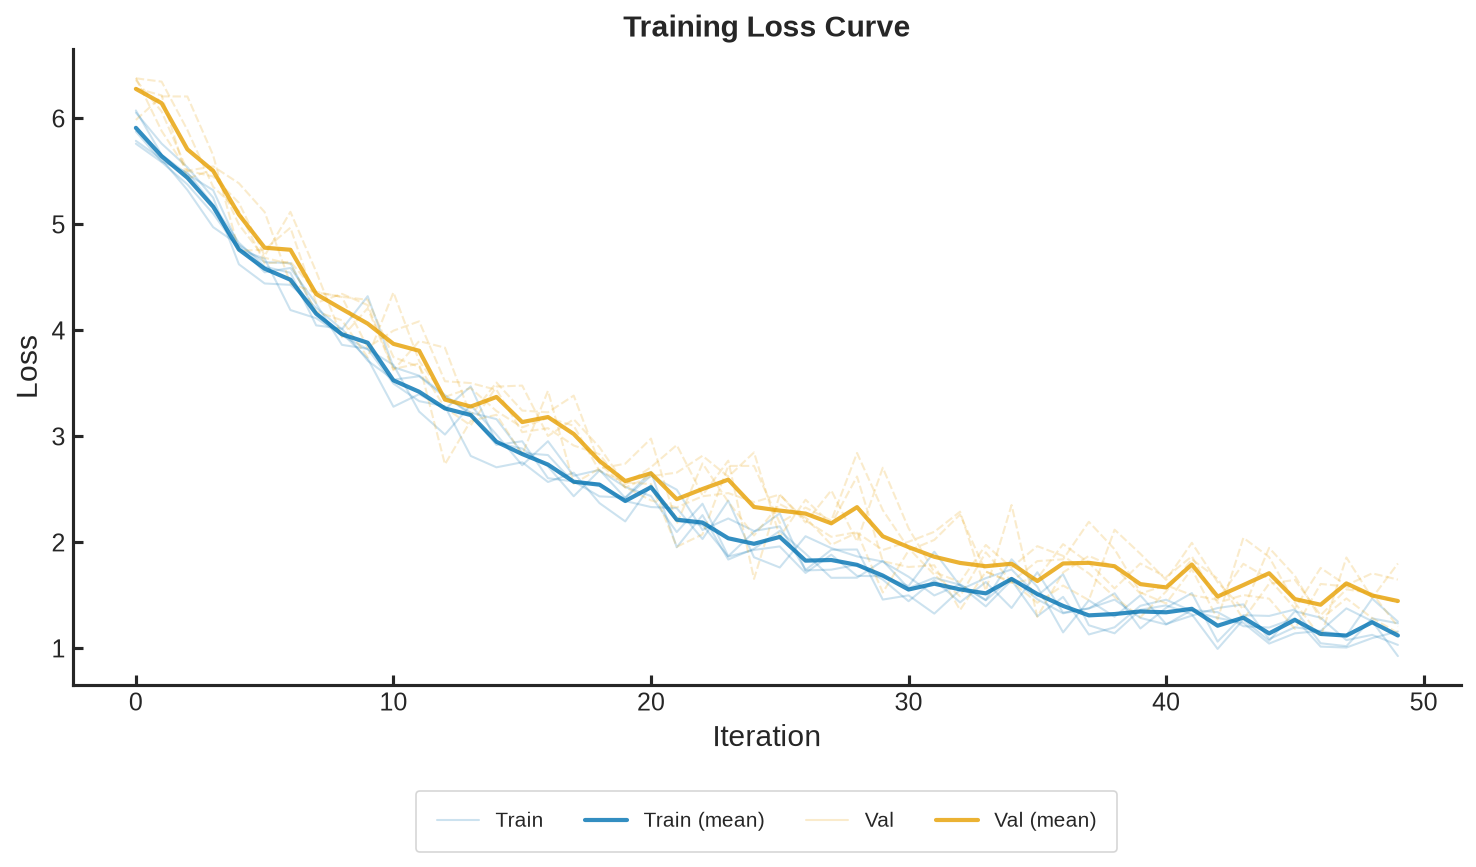

In [2]:
from lib.compute.plots.model_evaluation.loss_curve import loss_curve

np.random.seed(42)

n_folds = 5
n_iters = 50
records = []

for fold_i in range(n_folds):
    # 基础下降曲线 + 噪声
    base = 5 * np.exp(-np.arange(n_iters) / 15) + 1.0
    train_noise = np.random.normal(0, 0.15, n_iters)
    val_noise = np.random.normal(0, 0.25, n_iters)

    for t in range(n_iters):
        records.append(
            {
                "iteration": t,
                "loss": base[t] + train_noise[t],
                "type": "Train",
                "fold": f"Fold_{fold_i + 1}",
            }
        )
        records.append(
            {
                "iteration": t,
                "loss": base[t] + 0.3 + val_noise[t],  # validation 略高于 train
                "type": "Val",
                "fold": f"Fold_{fold_i + 1}",
            }
        )

loss_df = pd.DataFrame(records)
print(f"Data shape: {loss_df.shape}, folds: {loss_df['fold'].nunique()}, types: {loss_df['type'].unique()}")

fig = loss_curve(loss_df)
fig.tight_layout()
display(fig)

## 回归任务

### 预测散点图


Shape: (7200, 6)
Models: ['RF' 'XGB' 'CAT']
Types:  ['Train' 'Val' 'Test']
Targets: ['y_1' 'y_2' 'y_3' 'y_4']


/tmp/ipykernel_849274/3927855538.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


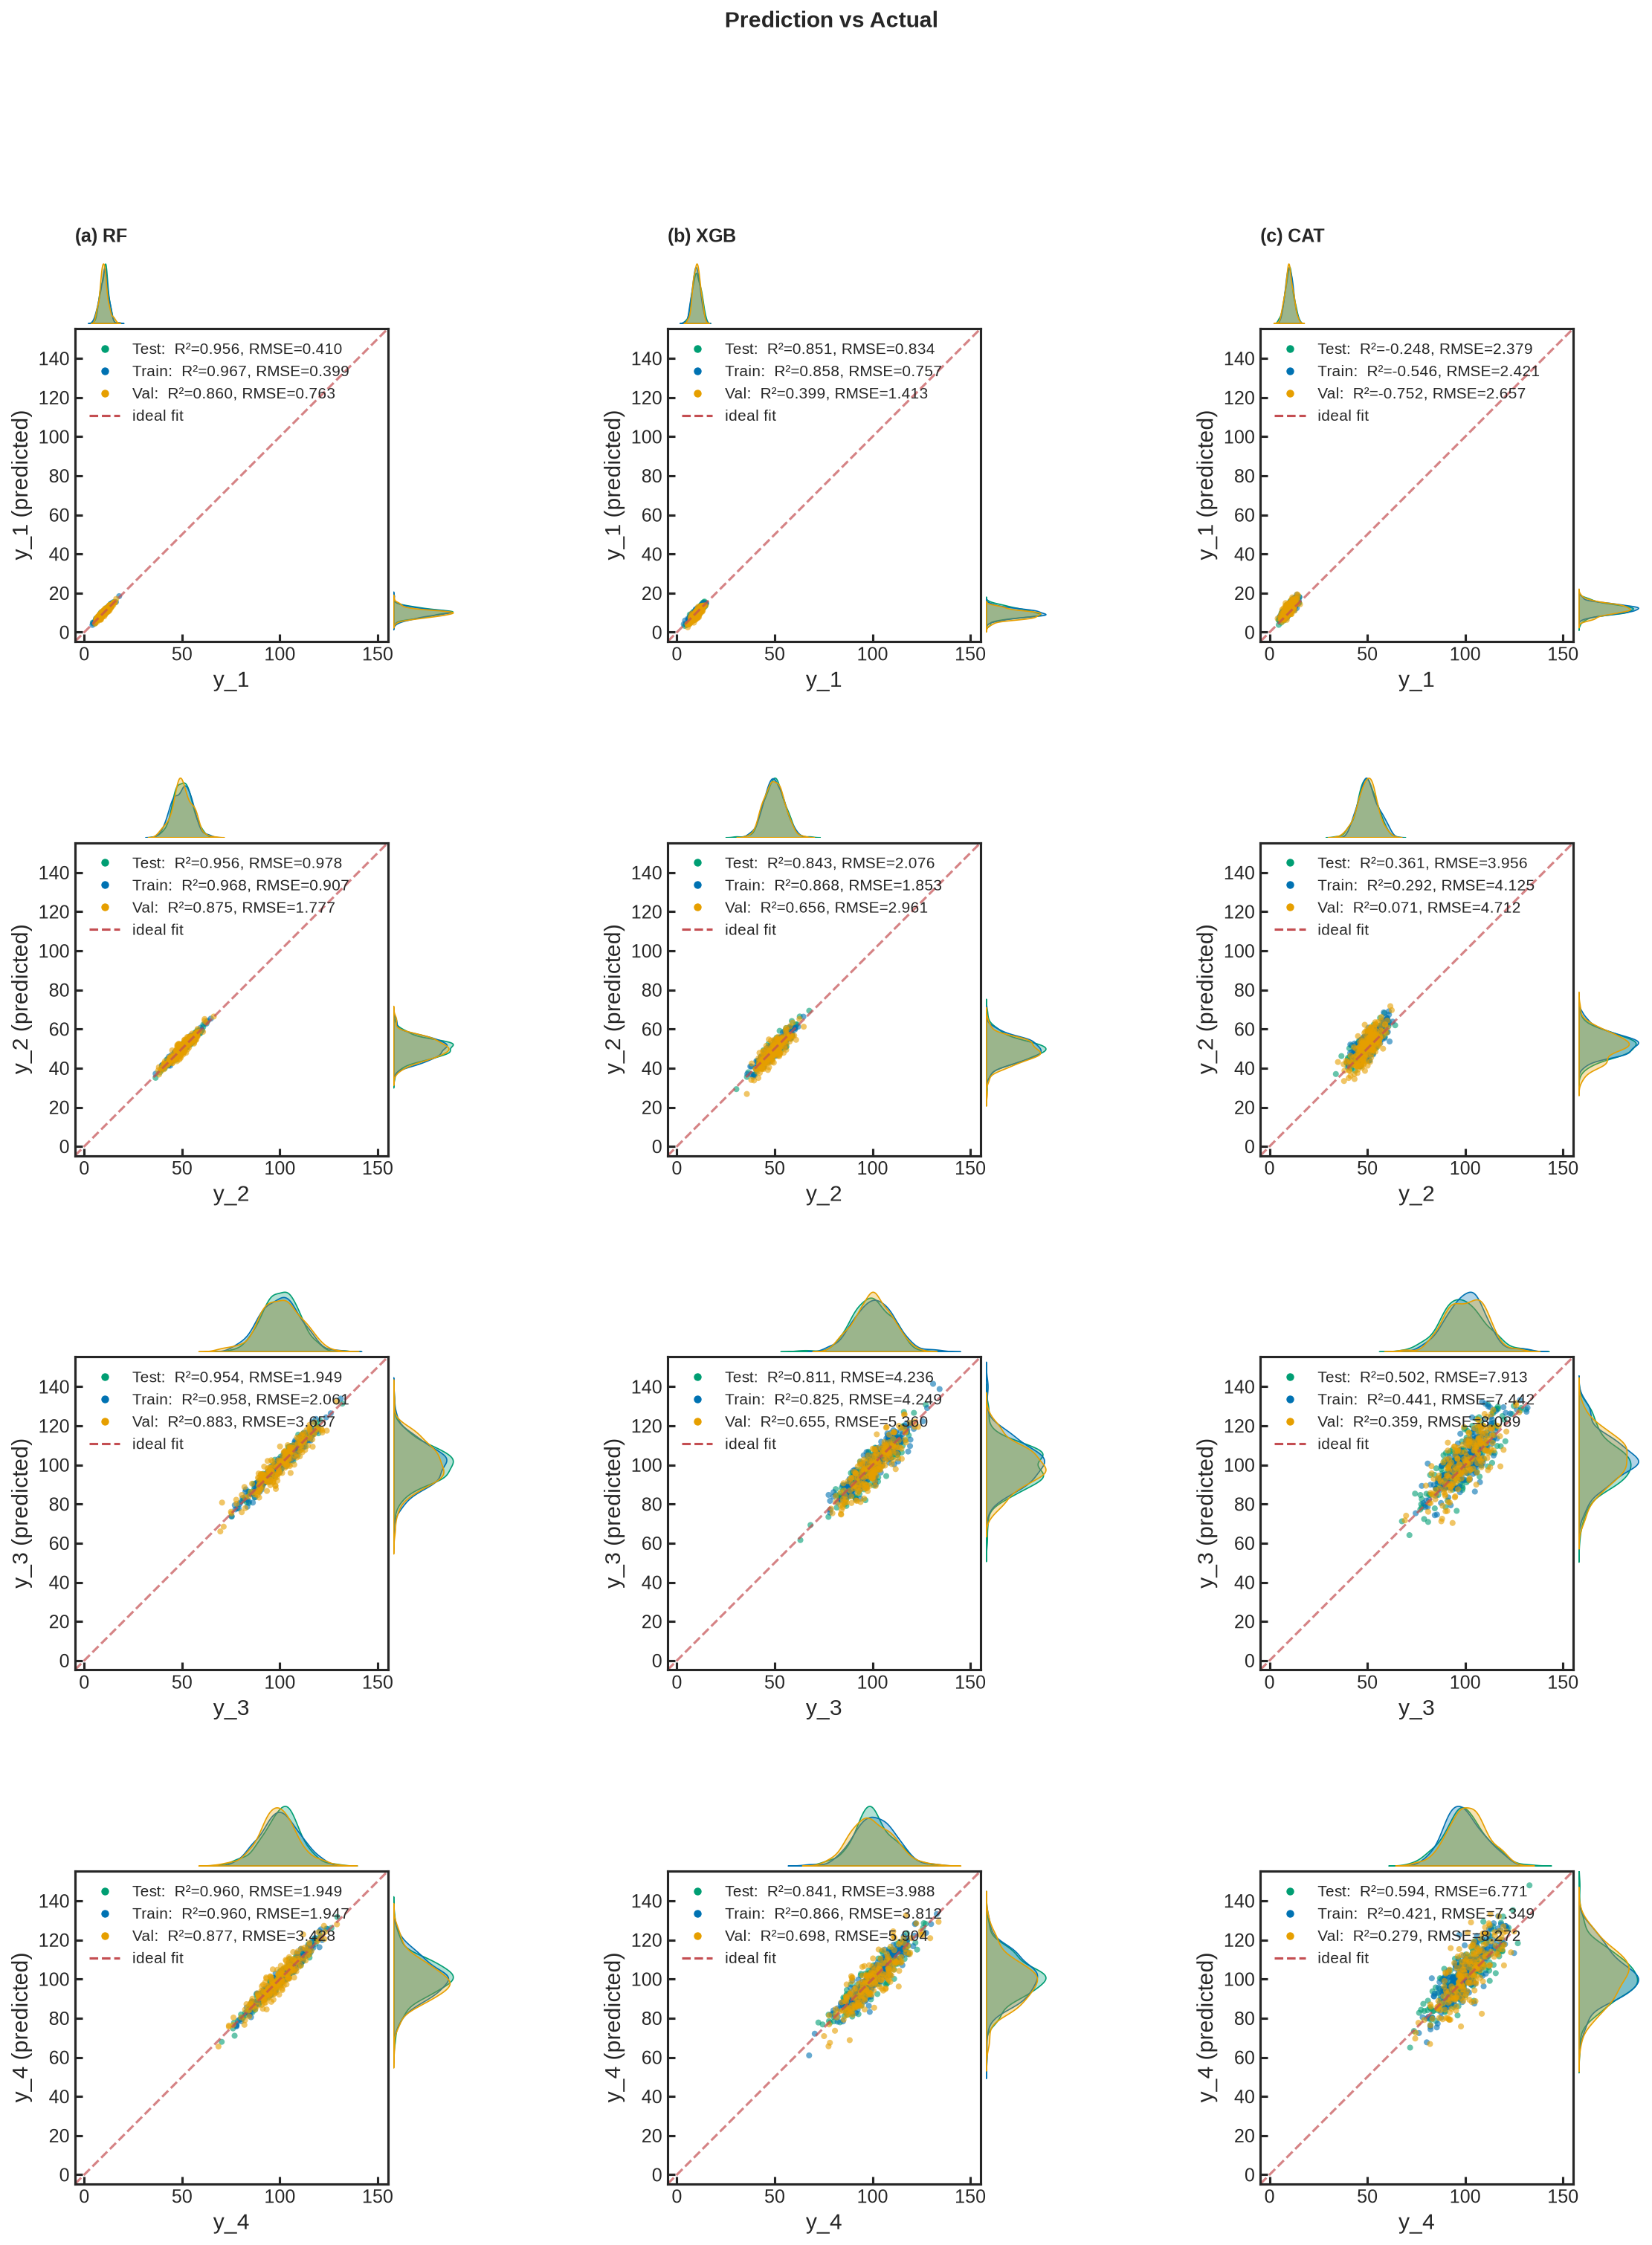

/tmp/ipykernel_849274/3927855538.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()


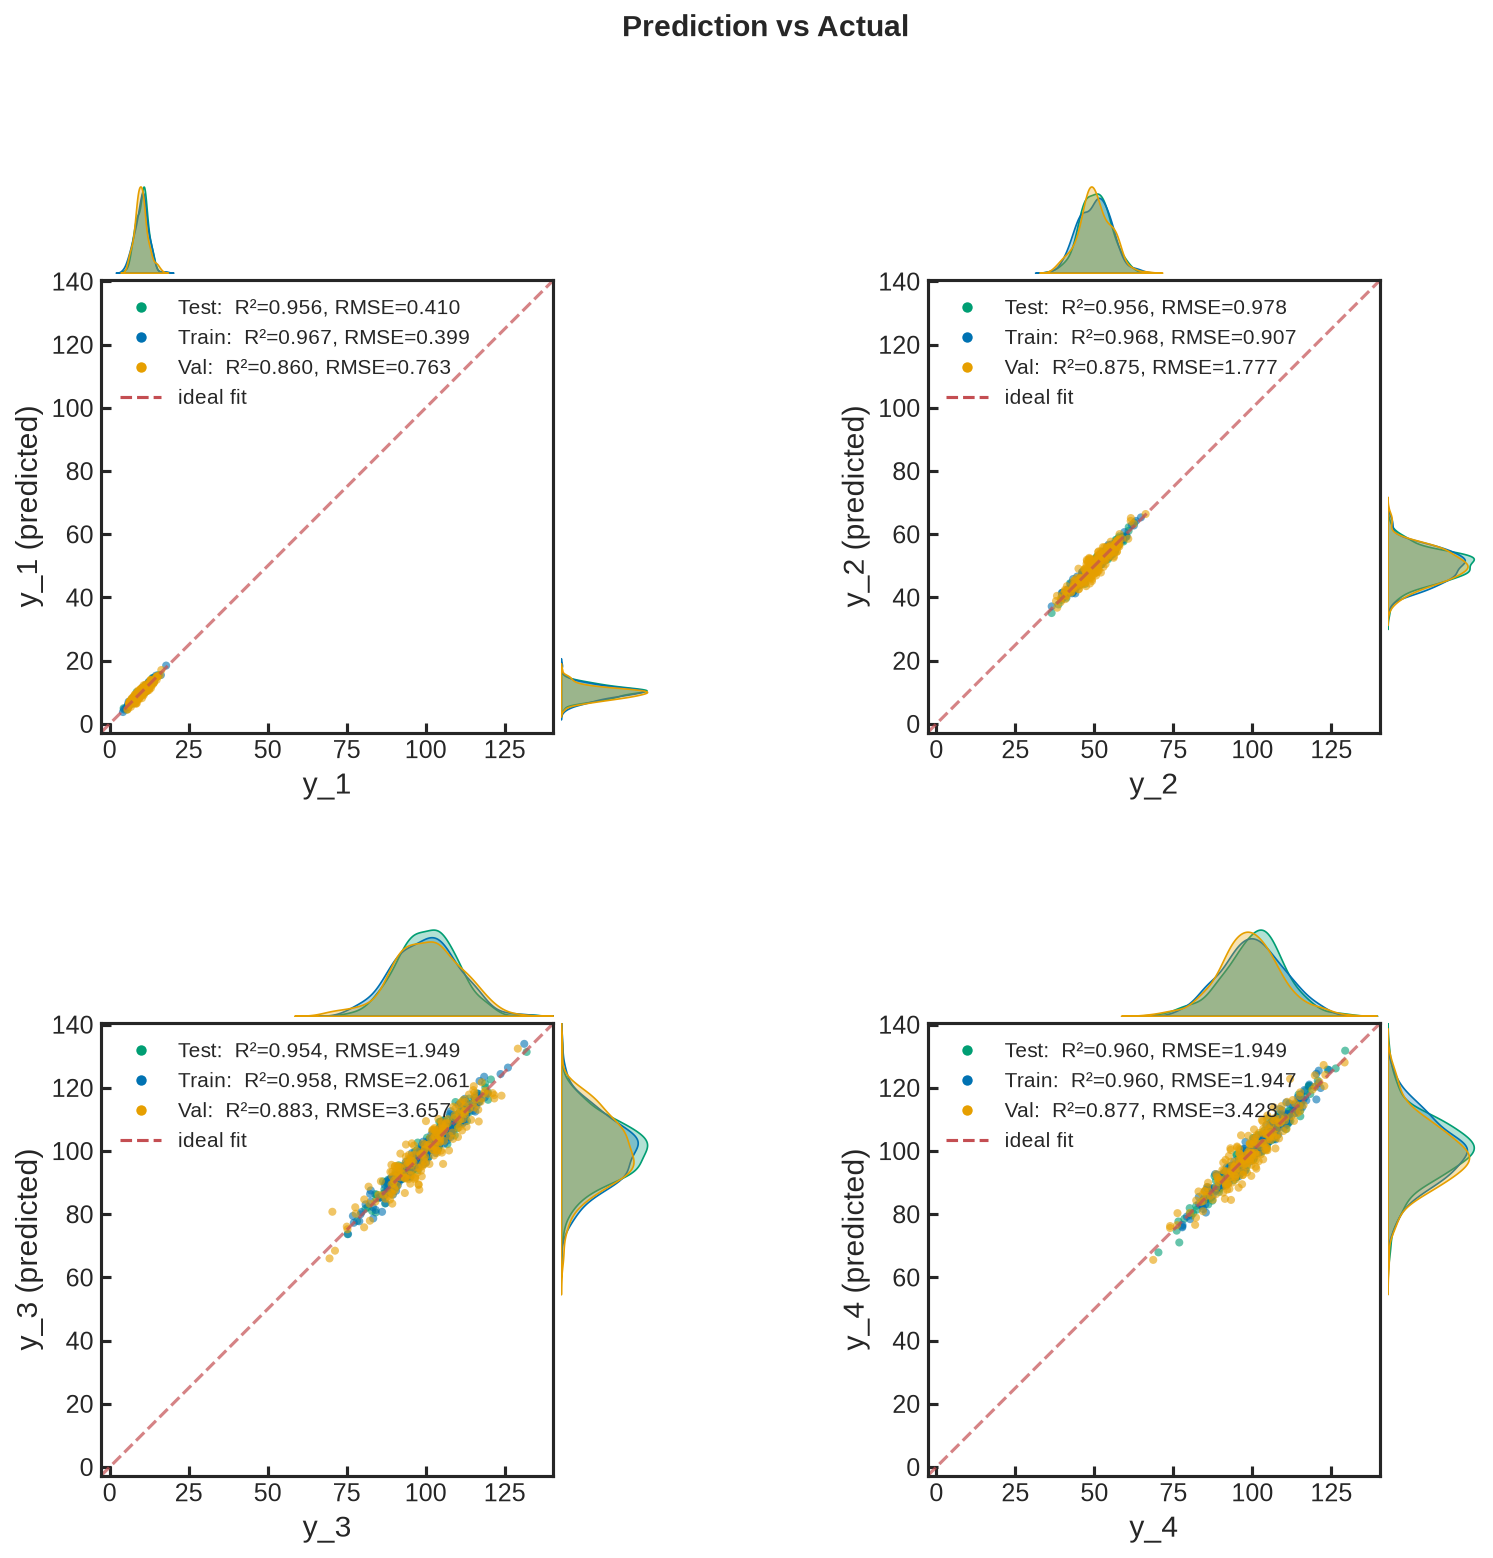

/tmp/ipykernel_849274/3927855538.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig3.tight_layout()


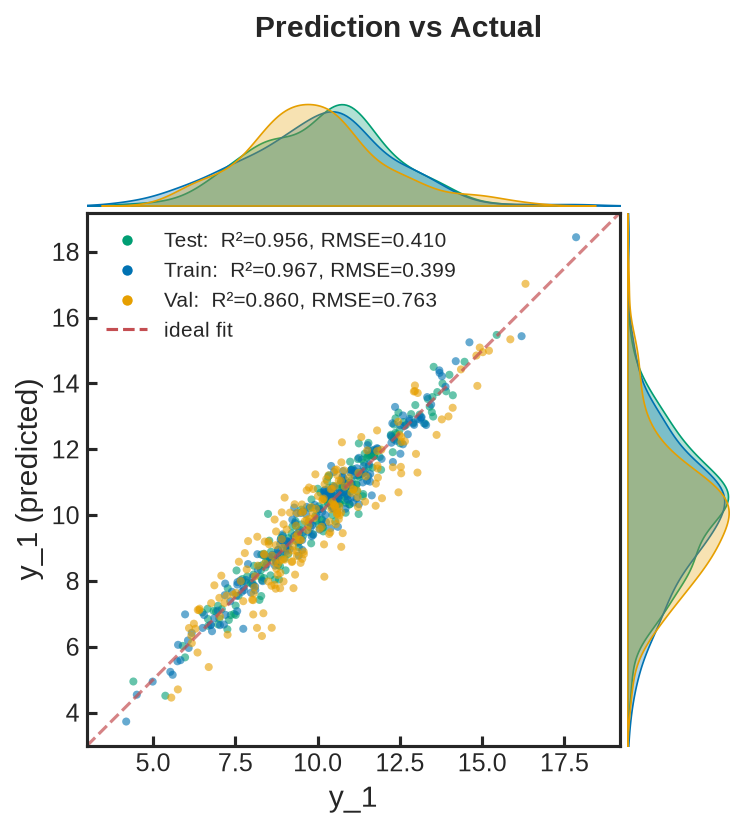

In [3]:
np.random.seed(42)

n_folds = 5
n_samples_per_fold = 40
y_names = ["y_1", "y_2", "y_3", "y_4"]
types = ["Train", "Val", "Test"]
models = ["RF", "XGB", "CAT"]

records = []

for fold_i in range(n_folds):
    for y_name in y_names:
        if y_name == "y_1":
            mu, sigma = 10, 2
        elif y_name == "y_2":
            mu, sigma = 50, 5
        else:
            mu, sigma = 100, 10

        for model_name in models:
            for type_val in types:
                y_true = np.random.normal(mu, sigma, n_samples_per_fold)

                # 不同模型有不同噪声水平：RF 最准，XGB 中等，CAT 略差
                noise_scale = {
                    "RF": 0.2,
                    "XGB": 0.4,
                    "CAT": 0.7,
                }[model_name]
                # Val 的噪声比 Train 略大
                if type_val == "Val":
                    noise_scale += 0.15

                noise = np.random.normal(0, noise_scale * sigma, n_samples_per_fold)
                y_pred = y_true + noise

                # 部分模型引入系统偏差
                if model_name == "CAT":
                    y_pred += 2.0  # CAT 整体高估
                elif model_name == "XGB" and type_val == "Val":
                    y_pred -= 1.0  # XGB 在 Val 上略低估

                for i in range(n_samples_per_fold):
                    records.append(
                        {
                            "model": model_name,
                            "fold": f"Fold_{fold_i + 1}",
                            "type": type_val,
                            "y_name": y_name,
                            "y": y_true[i],
                            "y_pred": y_pred[i],
                        }
                    )

long_df = pd.DataFrame(records)
print(f"Shape: {long_df.shape}")
print(f"Models: {long_df['model'].unique()}")
print(f"Types:  {long_df['type'].unique()}")
print(f"Targets: {long_df['y_name'].unique()}")

from lib.compute.plots.model_evaluation.regression.prediction_scatter import prediction_scatter

# 三模型 × 四目标 对比：col_wrap 自动固定为 3（模型数），每行一个 y_name
_, fig = prediction_scatter(long_df, point_size=15)
fig.tight_layout()
display(fig)

# 单模型（RF）多目标：col_wrap 由参数控制
df_rf = long_df[long_df["model"] == "RF"].drop(columns=["model"])
_, fig2 = prediction_scatter(df_rf, col_wrap=2, point_size=15)
fig2.tight_layout()
display(fig2)

# 单模型（RF）单目标：col_wrap 由参数控制
df_rf = long_df[long_df["model"] == "RF"].drop(columns=["model"])
_, fig3 = prediction_scatter(df_rf[df_rf["y_name"] == "y_1"], col_wrap=2, point_size=15)
fig3.tight_layout()
display(fig3)

### 残差散点图


/tmp/ipykernel_849274/2168861591.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


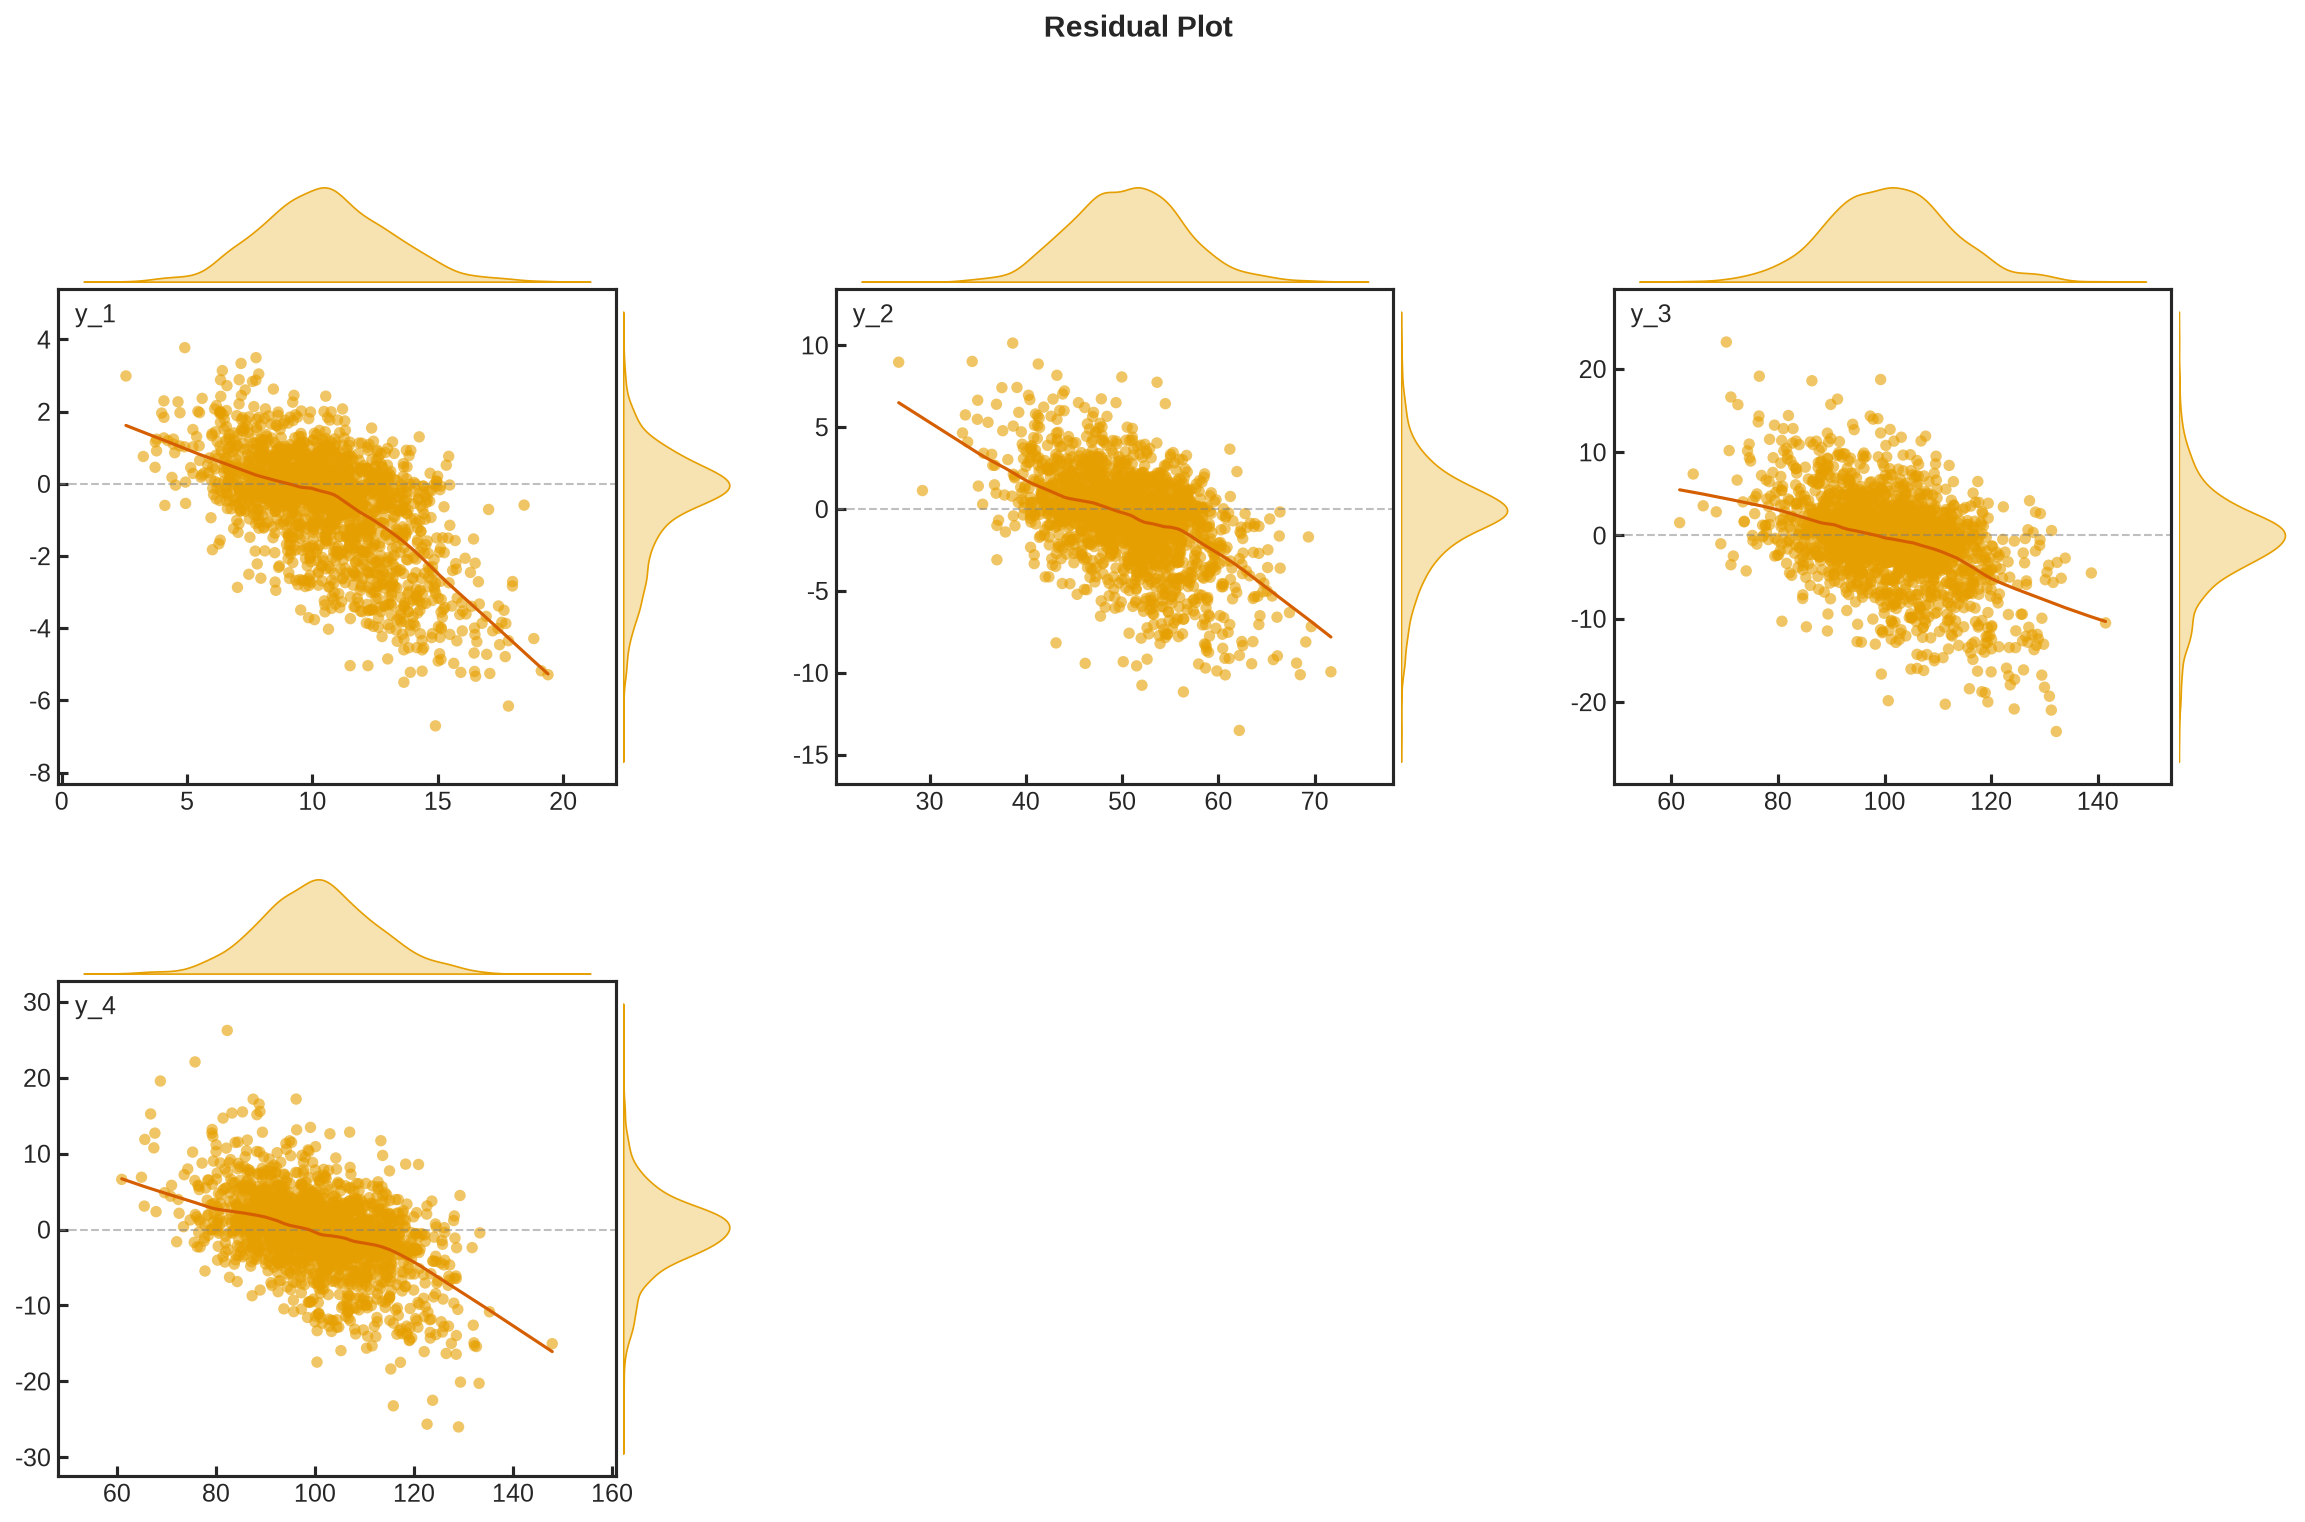

In [4]:
from lib.compute.plots.model_evaluation.regression.residual_scatter import residual_scatter

long_df["residual"] = long_df["y"] - long_df["y_pred"]
fig = residual_scatter(long_df)
fig.tight_layout()
display(fig)

### 误差分布图


/tmp/ipykernel_849274/2989150717.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


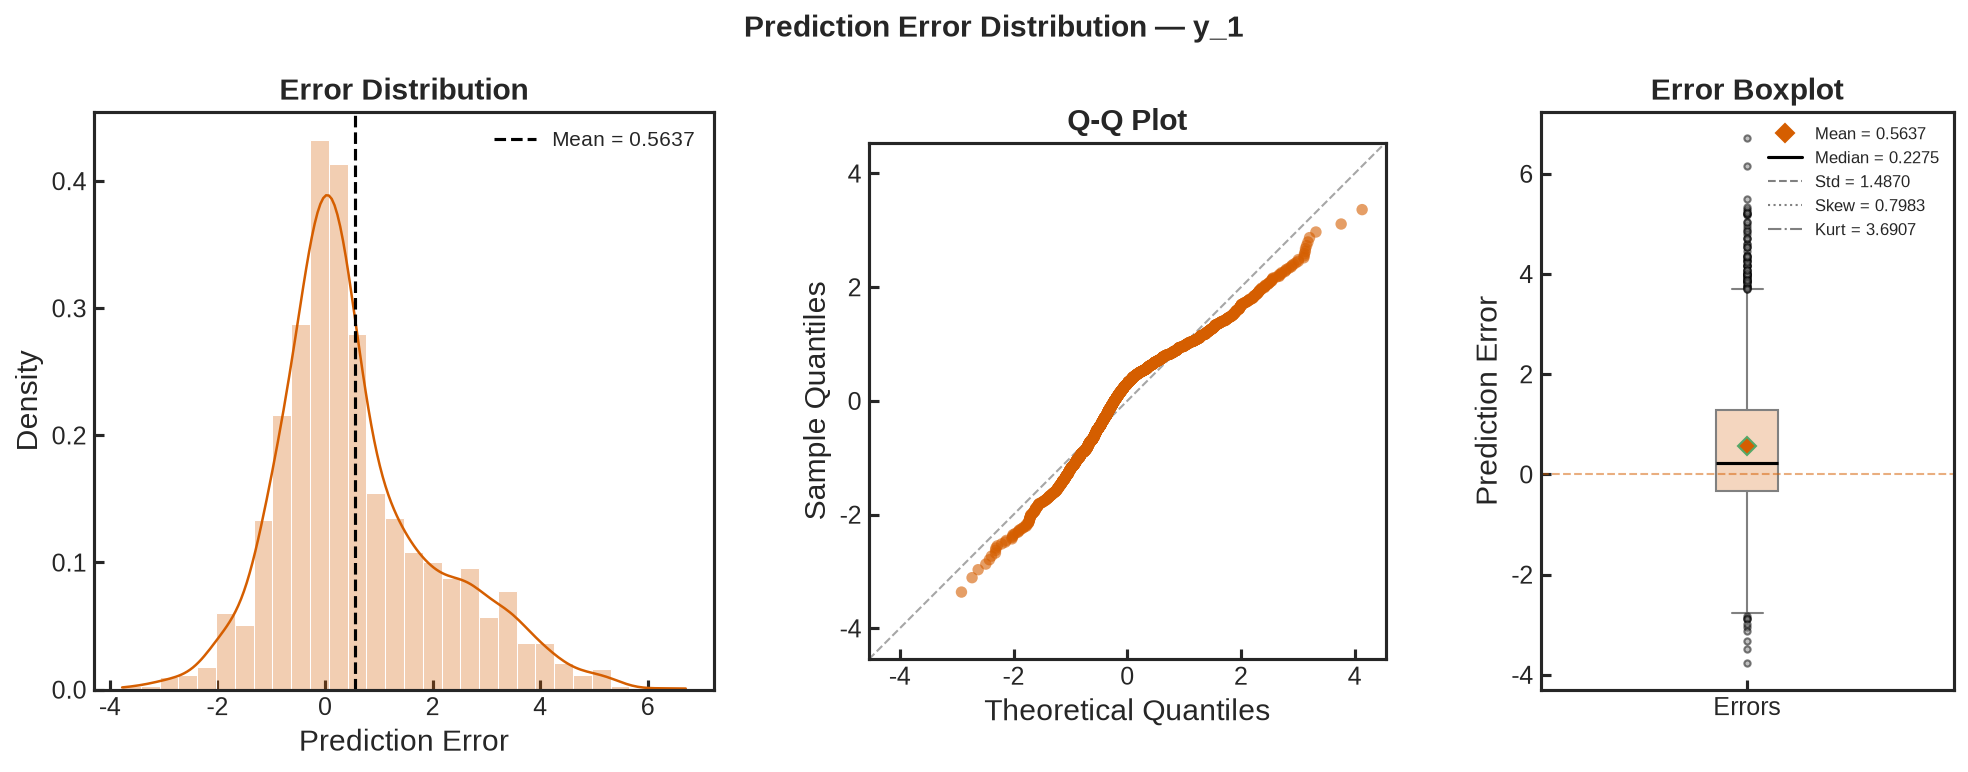

In [5]:
from lib.compute.plots.model_evaluation.regression.error_distribution import error_distribution

# 新接口：直接传入 df(fold, type, y_name, y, y_pred, error)，内部按 y_name 分组
error_df = long_df.assign(error=long_df["y_pred"] - long_df["y"])


fig = next(error_distribution(error_df))
fig.tight_layout()
display(fig)

## 分类任务

### 混淆矩阵 (confusion_matrix)

模拟 2 个目标变量 × 4 分类的预测混淆矩阵，验证热力图渲染和 cell 计数标注。

Shape: (1440, 5), models: 3, targets: 2


/tmp/ipykernel_849274/3580823838.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


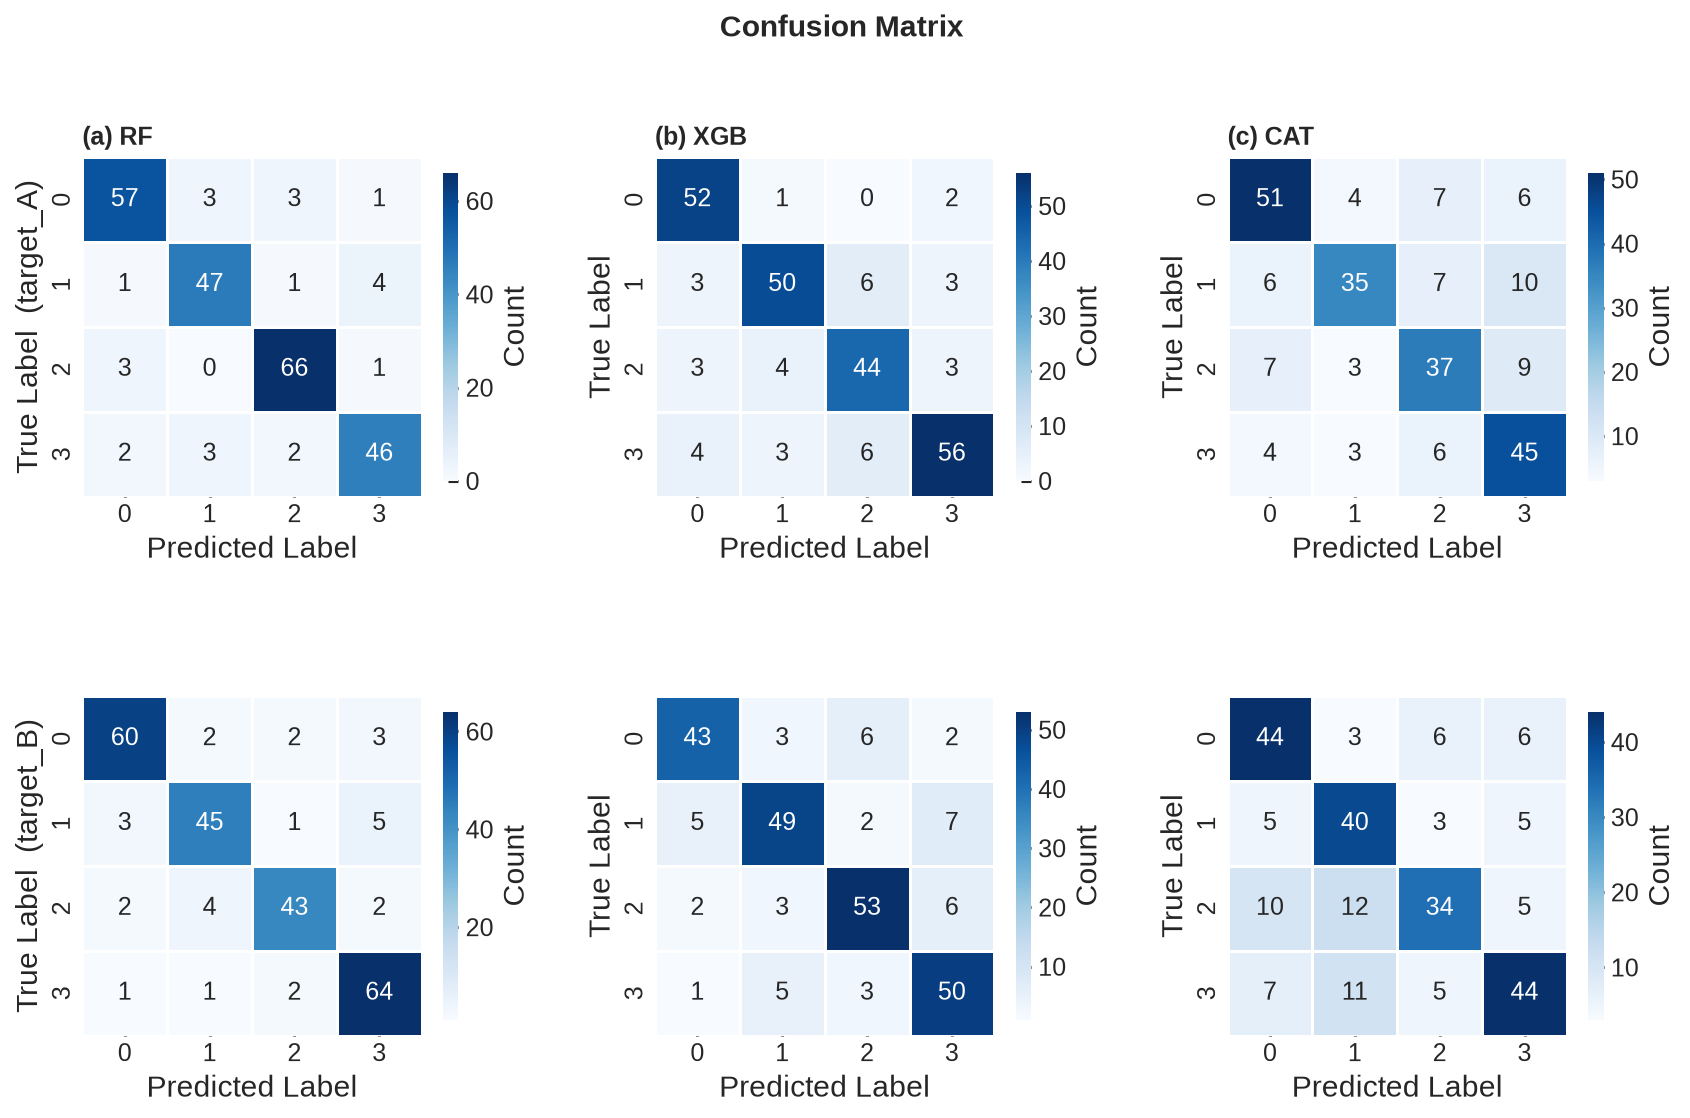

/tmp/ipykernel_849274/3580823838.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()


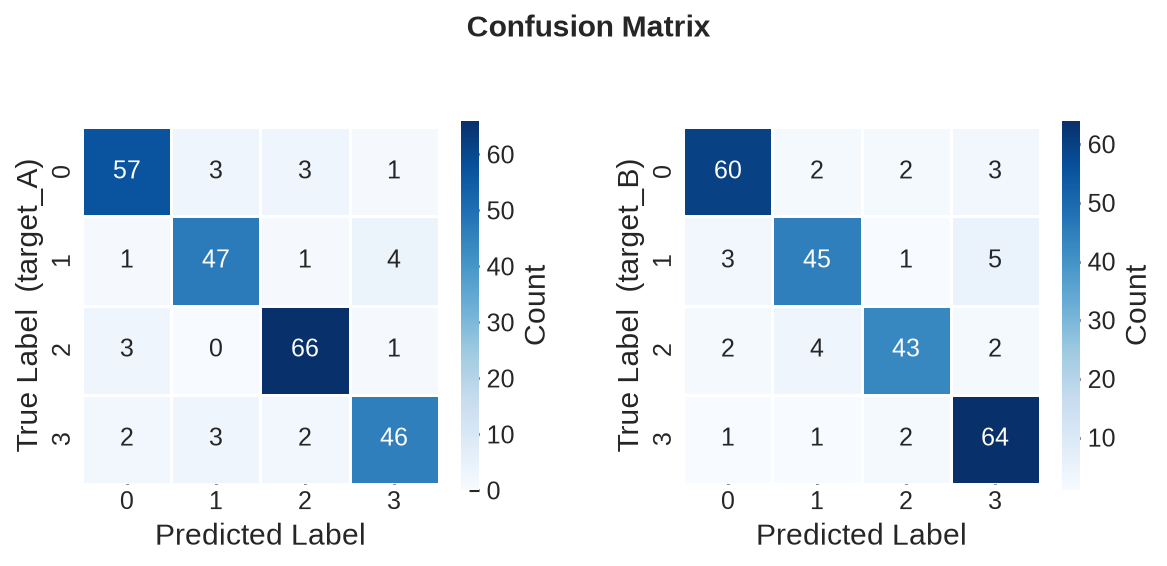

/tmp/ipykernel_849274/3580823838.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig3.tight_layout()


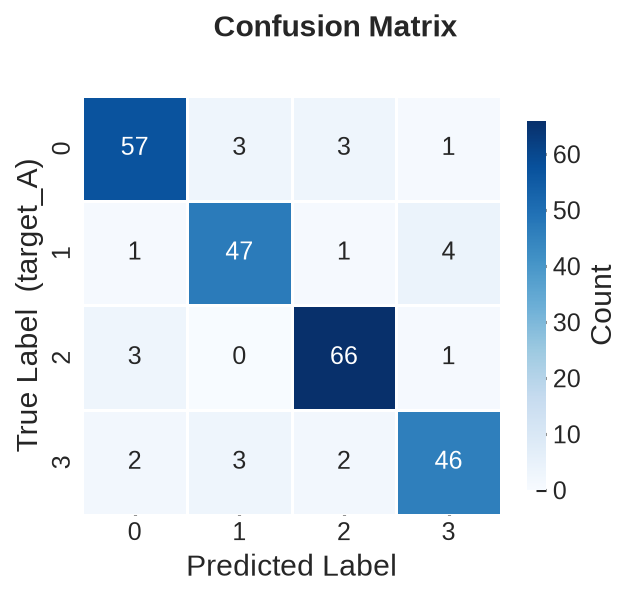

In [6]:
from lib.compute.plots.model_evaluation.classification.confusion_matrix import confusion_matrix

np.random.seed(42)

n_folds, n_per_fold = 3, 80
y_names = ["target_A", "target_B"]
models = ["RF", "XGB", "CAT"]
n_classes = 4

records = []
for fold_i in range(n_folds):
    for y_name in y_names:
        for model_name in models:
            acc = {"RF": 0.85, "XGB": 0.75, "CAT": 0.60}[model_name]
            for _ in range(n_per_fold):
                y_true = np.random.randint(0, n_classes)
                y_pred = y_true if np.random.random() < acc else np.random.randint(0, n_classes)
                records.append(
                    {
                        "model": model_name,
                        "fold": f"Fold_{fold_i + 1}",
                        "y_name": y_name,
                        "y": y_true,
                        "y_pred": y_pred,
                    }
                )
cm_df = pd.DataFrame(records)
print(f"Shape: {cm_df.shape}, models: {cm_df['model'].nunique()}, targets: {cm_df['y_name'].nunique()}")

# 三模型 × 二目标 对比：col_wrap 自动固定为 3
_, fig = confusion_matrix(cm_df)
fig.tight_layout()
display(fig)

# 单模型多目标：col_wrap 由参数控制
df_rf = cm_df[cm_df["model"] == "RF"]
_, fig2 = confusion_matrix(df_rf, col_wrap=2)
fig2.tight_layout()
display(fig2)

# 单模型单目标
df_rf_targe_a = df_rf[df_rf["y_name"] == "target_A"]
_, fig3 = confusion_matrix(df_rf_targe_a, col_wrap=2)
fig3.tight_layout()
display(fig3)

## 泰勒图

对比不同模型对同一数据的建模预测性能

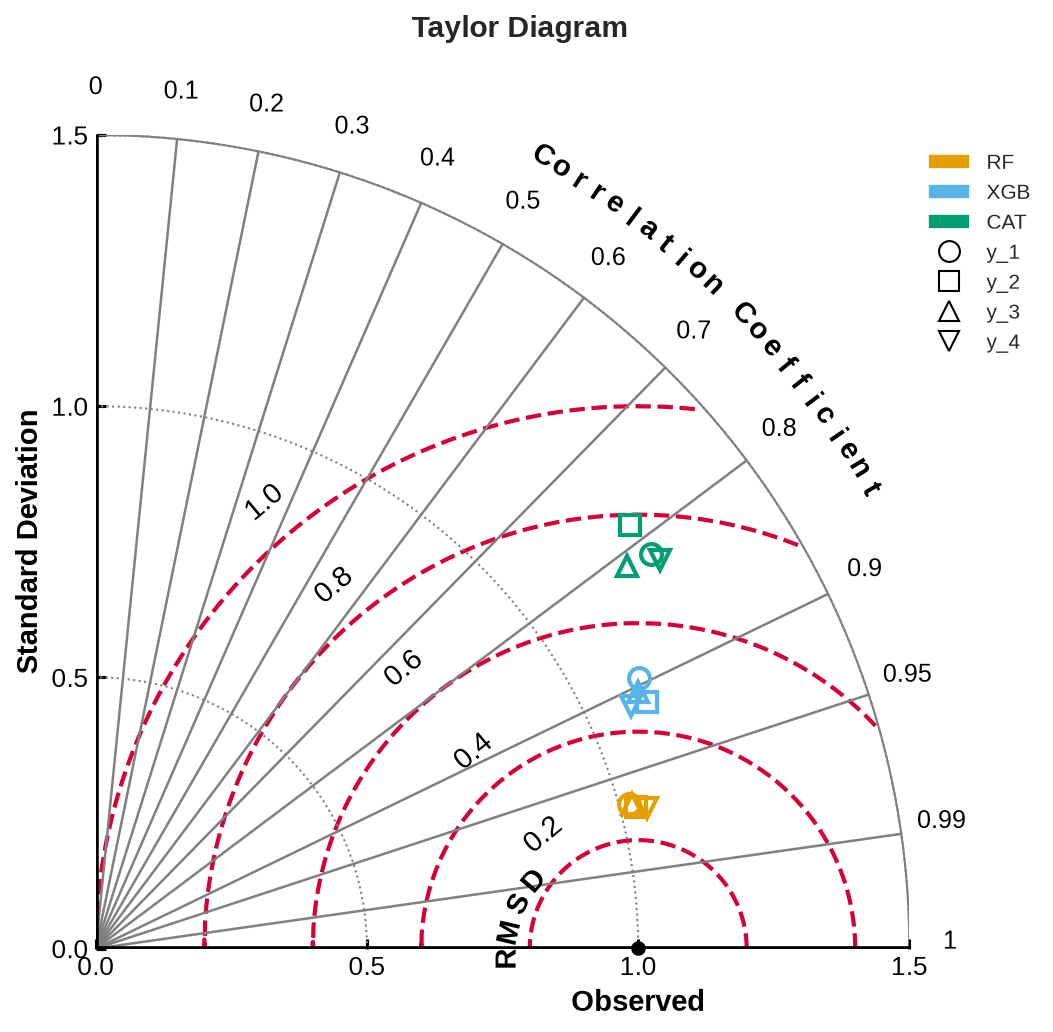

In [7]:
from lib.compute.plots.model_evaluation.regression.taylor_diagram import taylor_diagram

# 直接使用预测散点图中 long_df 的原始预测数据（格式统一）
# long_df: model, fold, type, y_name, y, y_pred
# 泰勒图内部按 (y_name, model) 分组计算 sigma_ratio / correlation / rmse_norm
_, fig = taylor_diagram(long_df)
fig.tight_layout()
display(fig)

# 模型解释性

## SHAP Summary (beeswarm with feature importance)

全局特征重要性分布，模拟 shap.Explanation 进行 beeswarm 渲染。

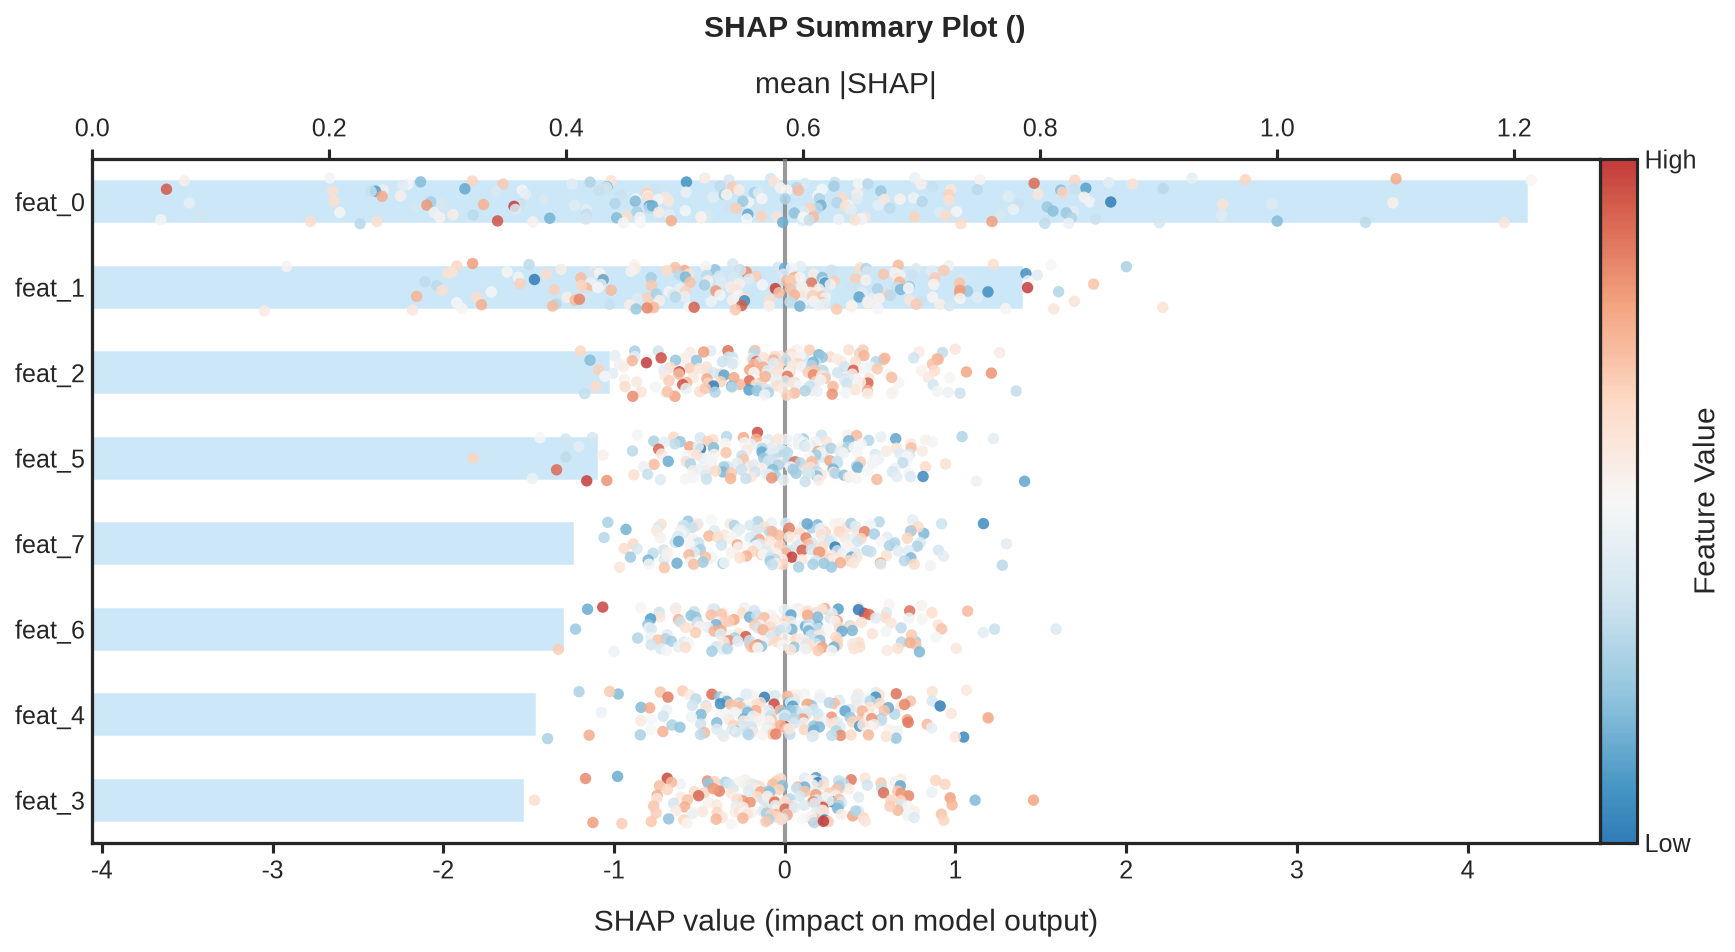

In [40]:
import shap
from lib.compute.plots.model_interpretability.shap.summary import shap_summary

np.random.seed(42)

n_samples, n_features = 200, 8
feature_names = [f"feat_{i}" for i in range(n_features)]

rng = np.random.default_rng(42)
shap_values = rng.normal(0, 0.5, (n_samples, n_features))
shap_values[:, 0] = rng.normal(0, 1.5, n_samples)  # feat_0 最重要
shap_values[:, 1] = rng.normal(0, 1.0, n_samples)  # feat_1 次重要
base_values = np.full(n_samples, 0.0)
data = rng.normal(0, 1, (n_samples, n_features))

explanation = shap.Explanation(
    values=shap_values,
    base_values=base_values,
    data=data,
    feature_names=feature_names,
)

df = pd.DataFrame()
df.attrs["explanation"] = explanation
_, fig = next(shap_summary((df,)))
fig.subplots_adjust(left=0, right=1)
display(fig)

## SHAP 依赖图（含交互着色）

构造 SHAP interaction 矩阵，验证散点按最强交互特征值着色 + 右侧 Feature Value 色条。

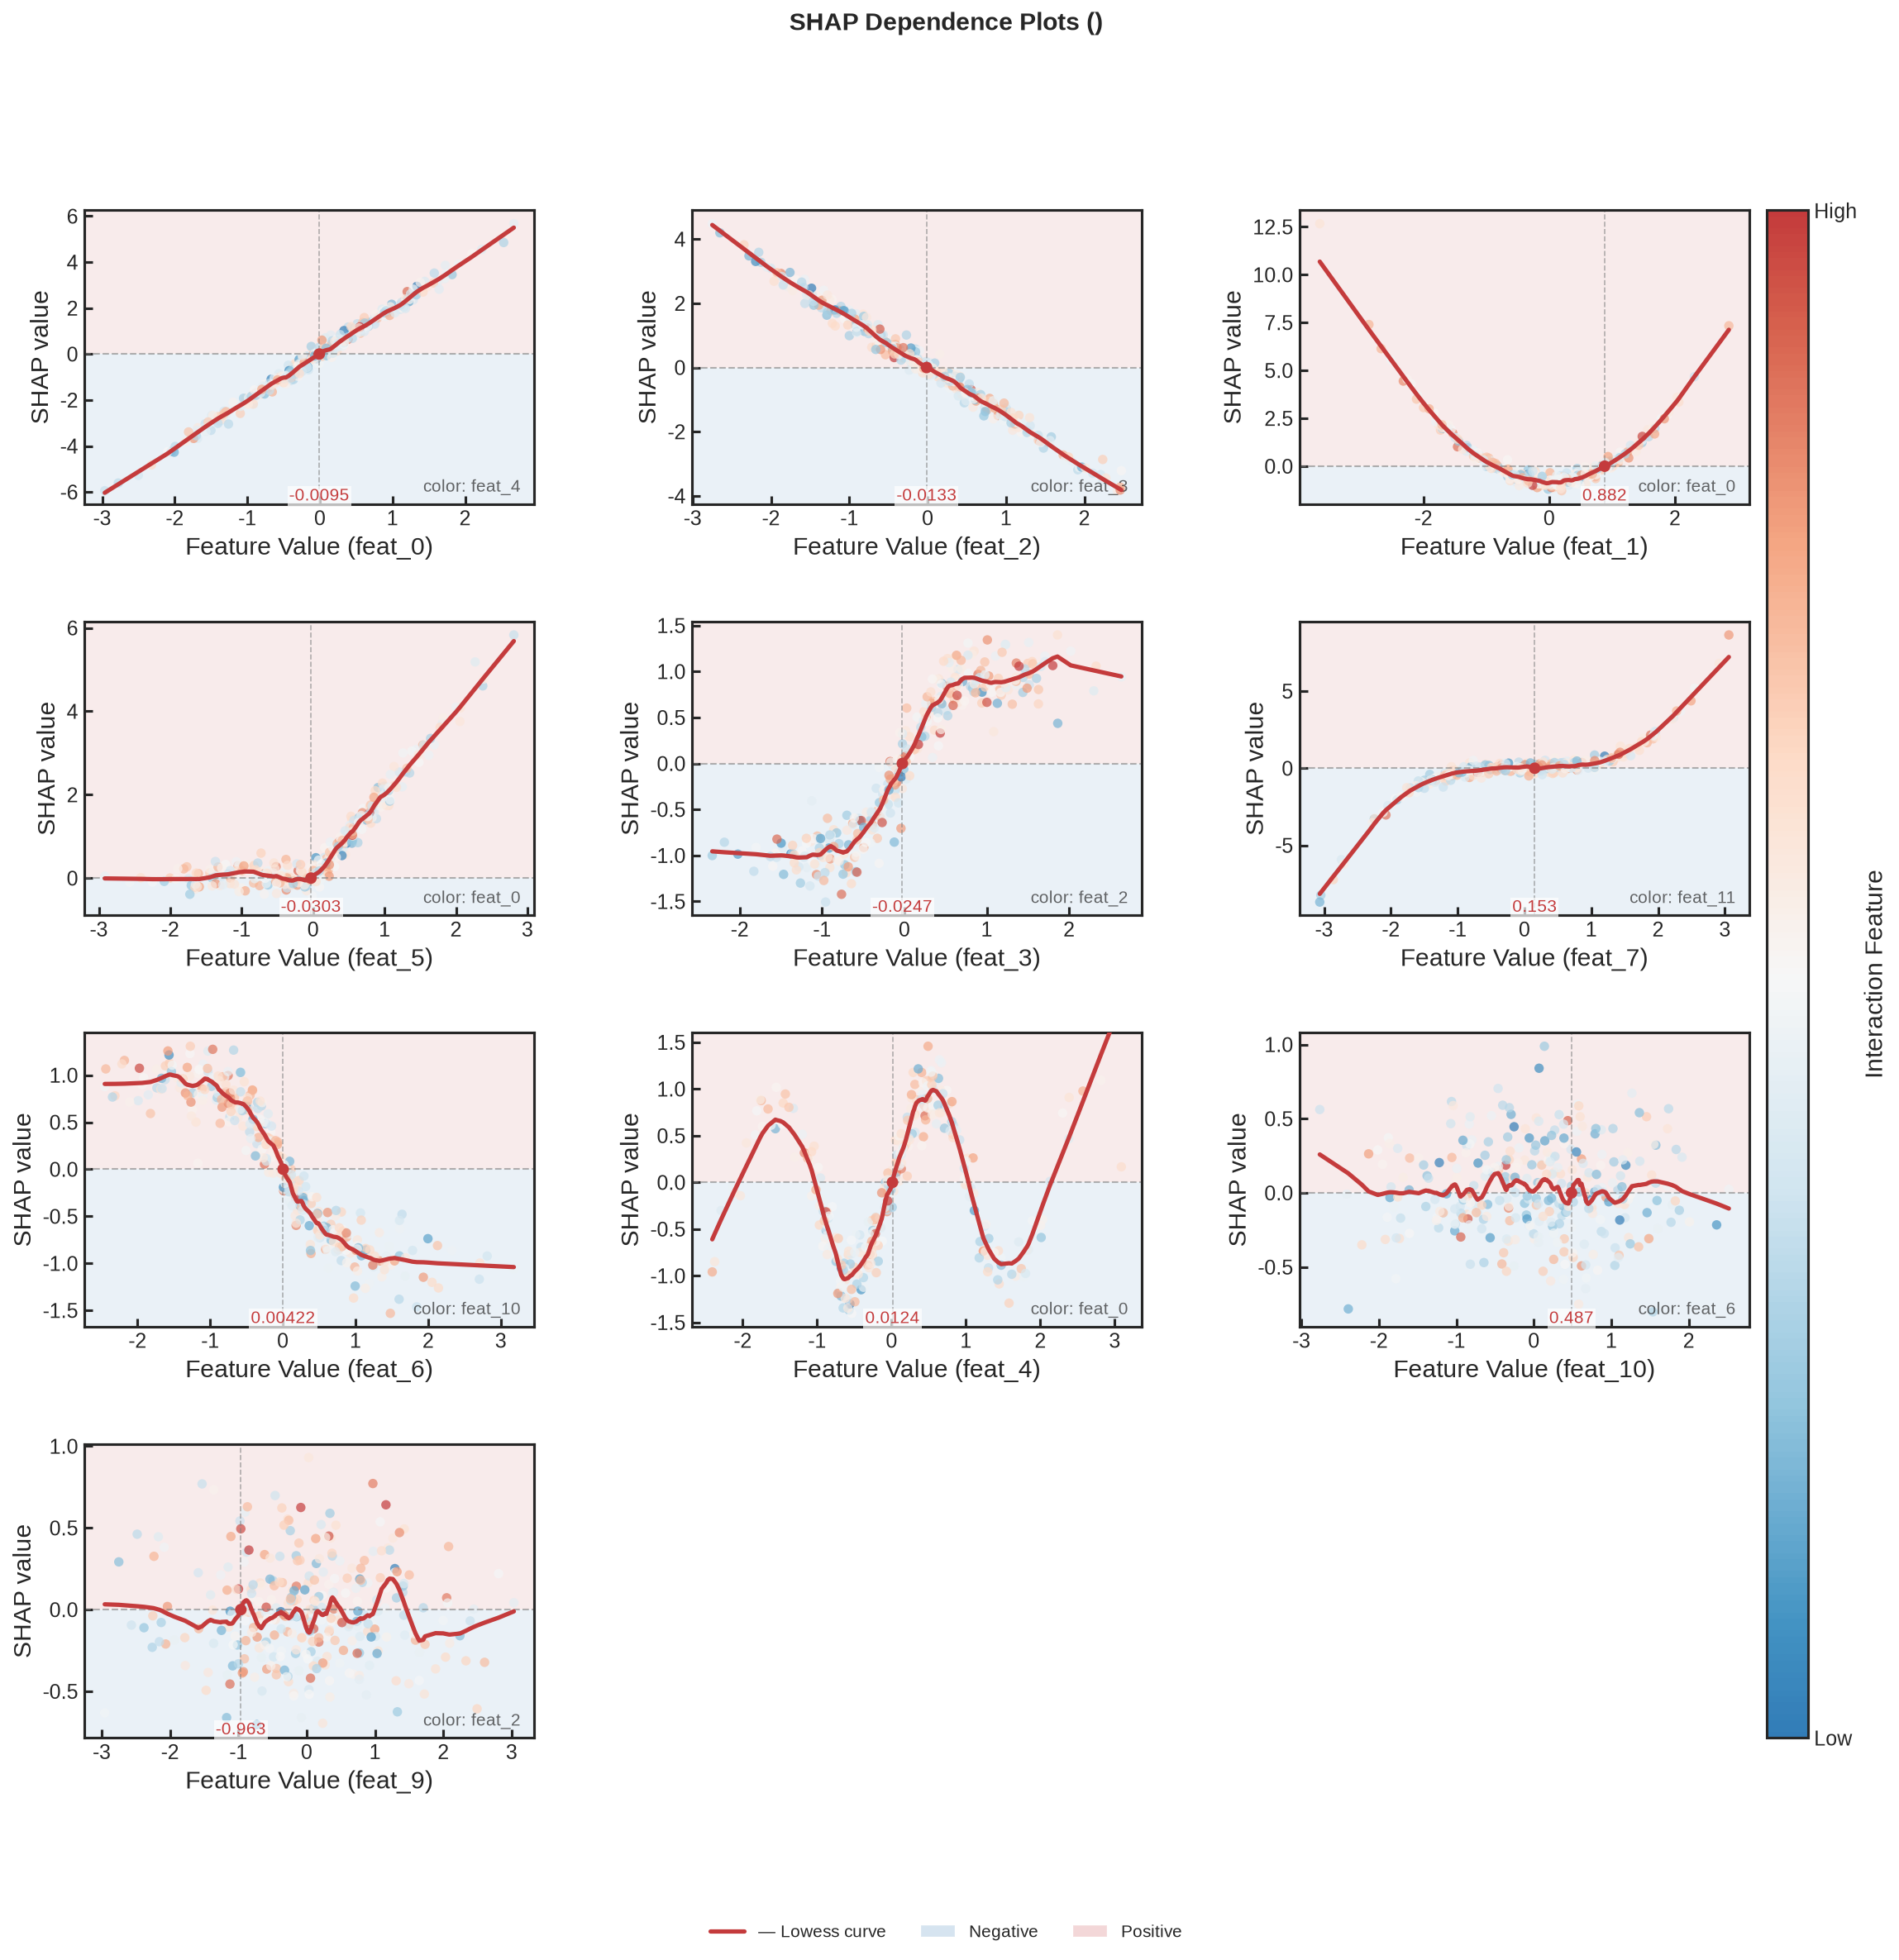

In [43]:
import shap
from lib.compute.plots.model_interpretability.shap.dependence import shap_dependence

np.random.seed(42)

n_samples, n_features = 300, 12
feature_names = [f"feat_{i}" for i in range(n_features)]

rng = np.random.default_rng(42)
data = rng.normal(0, 1, (n_samples, n_features))

# 构造 SHAP values：feat_0 线性、feat_1 U 形、feat_2 负线性、feat_3 sigmoid
shap_values = np.zeros((n_samples, n_features))
shap_values[:, 0] = data[:, 0] * 2.0 + rng.normal(0, 0.2, n_samples)
shap_values[:, 1] = (data[:, 1] ** 2 - 0.8) + rng.normal(0, 0.2, n_samples)
shap_values[:, 2] = -data[:, 2] * 1.5 + rng.normal(0, 0.2, n_samples)
shap_values[:, 3] = np.tanh(data[:, 3] * 2) + rng.normal(0, 0.2, n_samples)
shap_values[:, 4] = np.sin(data[:, 4] * 3) + rng.normal(0, 0.2, n_samples)
shap_values[:, 5] = np.where(data[:, 5] > 0, data[:, 5] * 2, 0) + rng.normal(0, 0.2, n_samples)
shap_values[:, 6] = -np.tanh(data[:, 6] * 1.5) + rng.normal(0, 0.2, n_samples)
shap_values[:, 7] = data[:, 7] ** 3 * 0.3 + rng.normal(0, 0.2, n_samples)
shap_values[:, 8:] = rng.normal(0, 0.3, (n_samples, n_features - 8))


base_values = np.full(n_samples, 0.0)

explanation = shap.Explanation(
    values=shap_values,
    base_values=base_values,
    data=data,
    feature_names=feature_names,
)


df_inter = pd.DataFrame()
df_inter.attrs["explanation"] = explanation

_, fig = next(shap_dependence((df_inter,), top_n=10, col_wrap=3, lowess_frac=0.1))
fig.subplots_adjust(left=0, right=1)
display(fig)

## SHAP 单样本瀑布图 (sample_waterfall)

单样本从 base value 到 prediction 的逐特征贡献分解，红色推高 / 蓝色拉低预测。

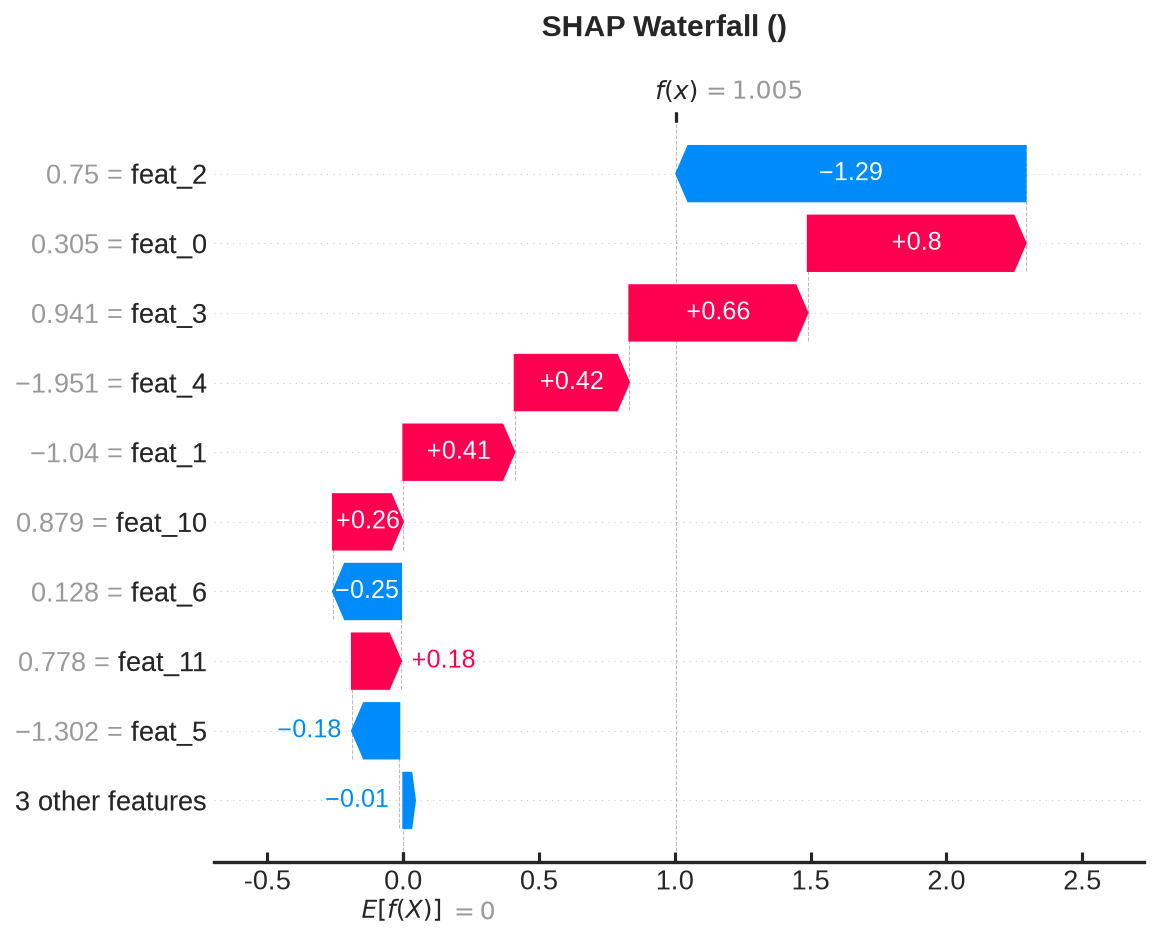

In [10]:
from lib.compute.plots.model_interpretability.shap.sample_waterfall import sample_waterfall

explanation = df_inter.attrs["explanation"]

wf_df = pd.DataFrame()
wf_df.attrs["explanation"] = explanation
wf_df.attrs["sample_index"] = 0
wf_df.attrs["max_display"] = 10

_, fig = next(sample_waterfall((wf_df,), sample_idx=0, max_display=10))
display(fig)

## SHAP 分类特征依赖图 (categorical features)

验证分类特征（object/string dtype）在 `shap_dependence` 和 `shap_summary` 中的正确渲染：
- x 轴：分类列用 `pd.factorize` codes 定位，ticks 回贴 category 名
- LOWESS 曲线 / 转折点：分类列跳过（无序变量无距离语义）
- 交互伙伴：分类列同样 factorize，单一分类交互伙伴时 colorbar 标 category 名
- Summary 图：分类列 codes 归一化着色</cell>


=== shap_dependence (4 features, 2 categorical + 2 numeric) ===


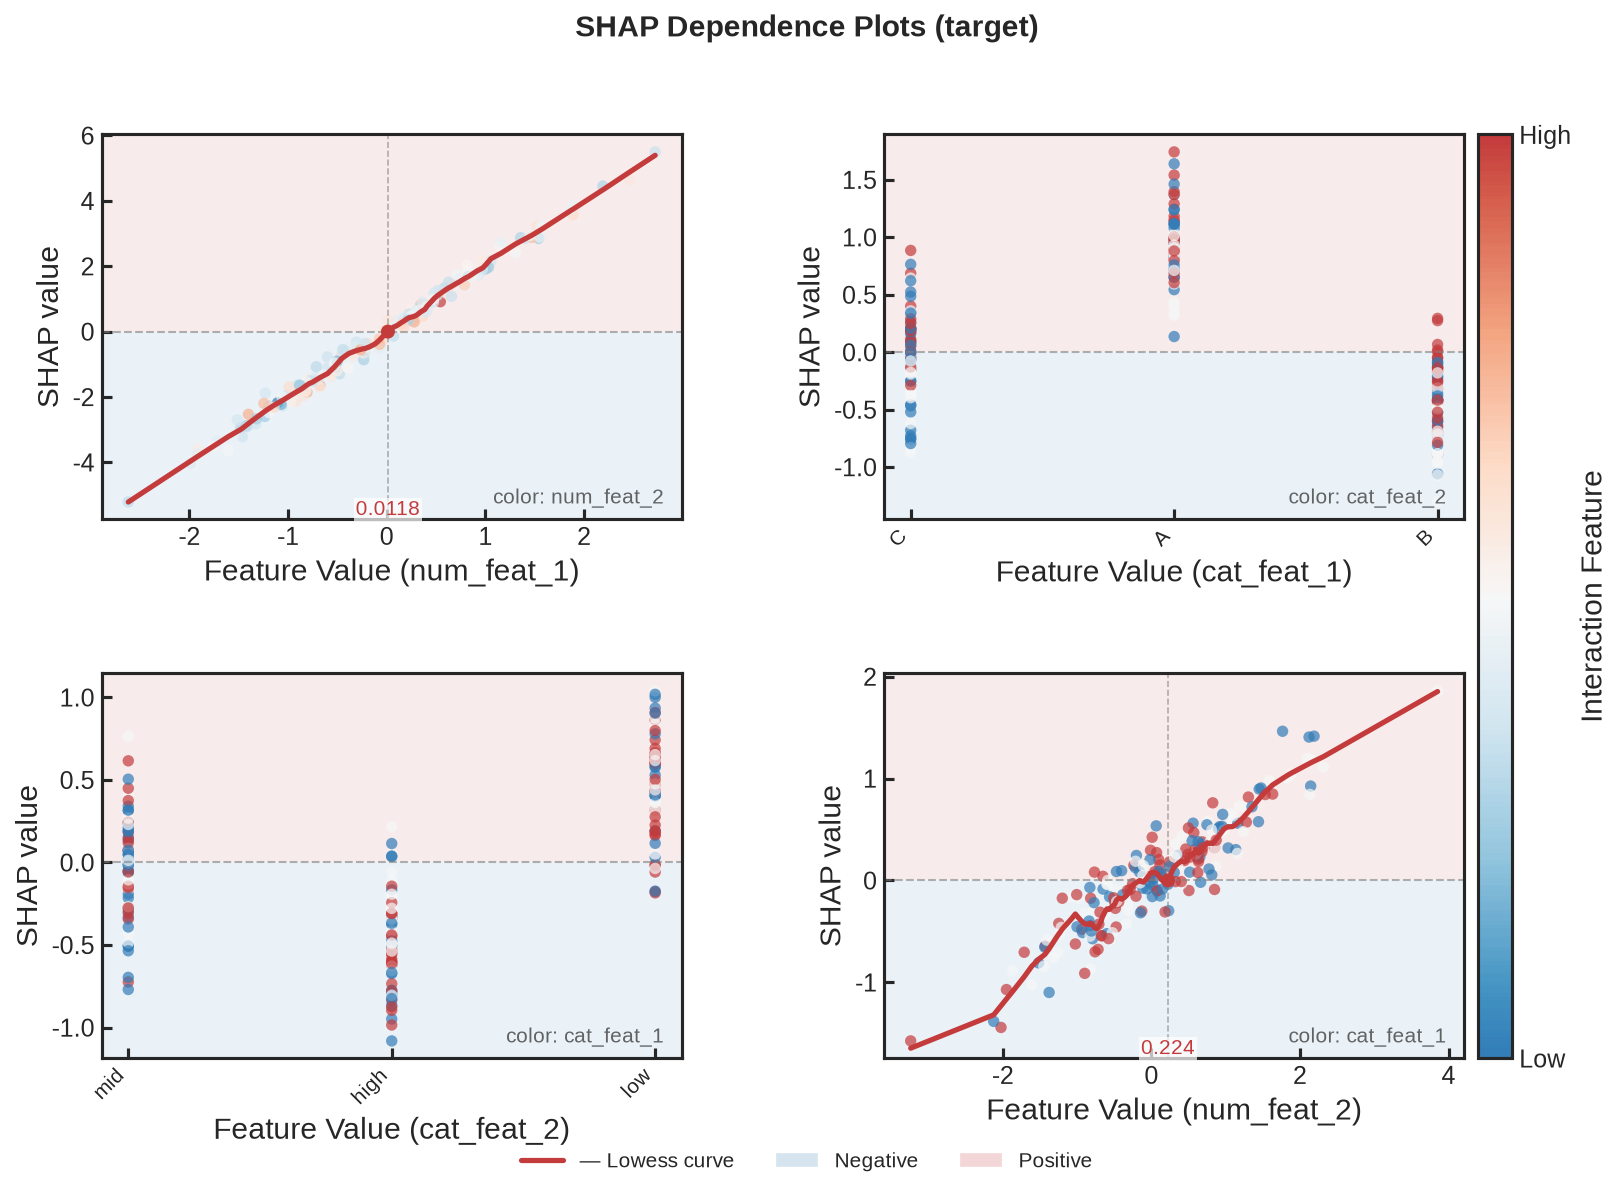

=== shap_summary (4 features, 2 categorical + 2 numeric) ===


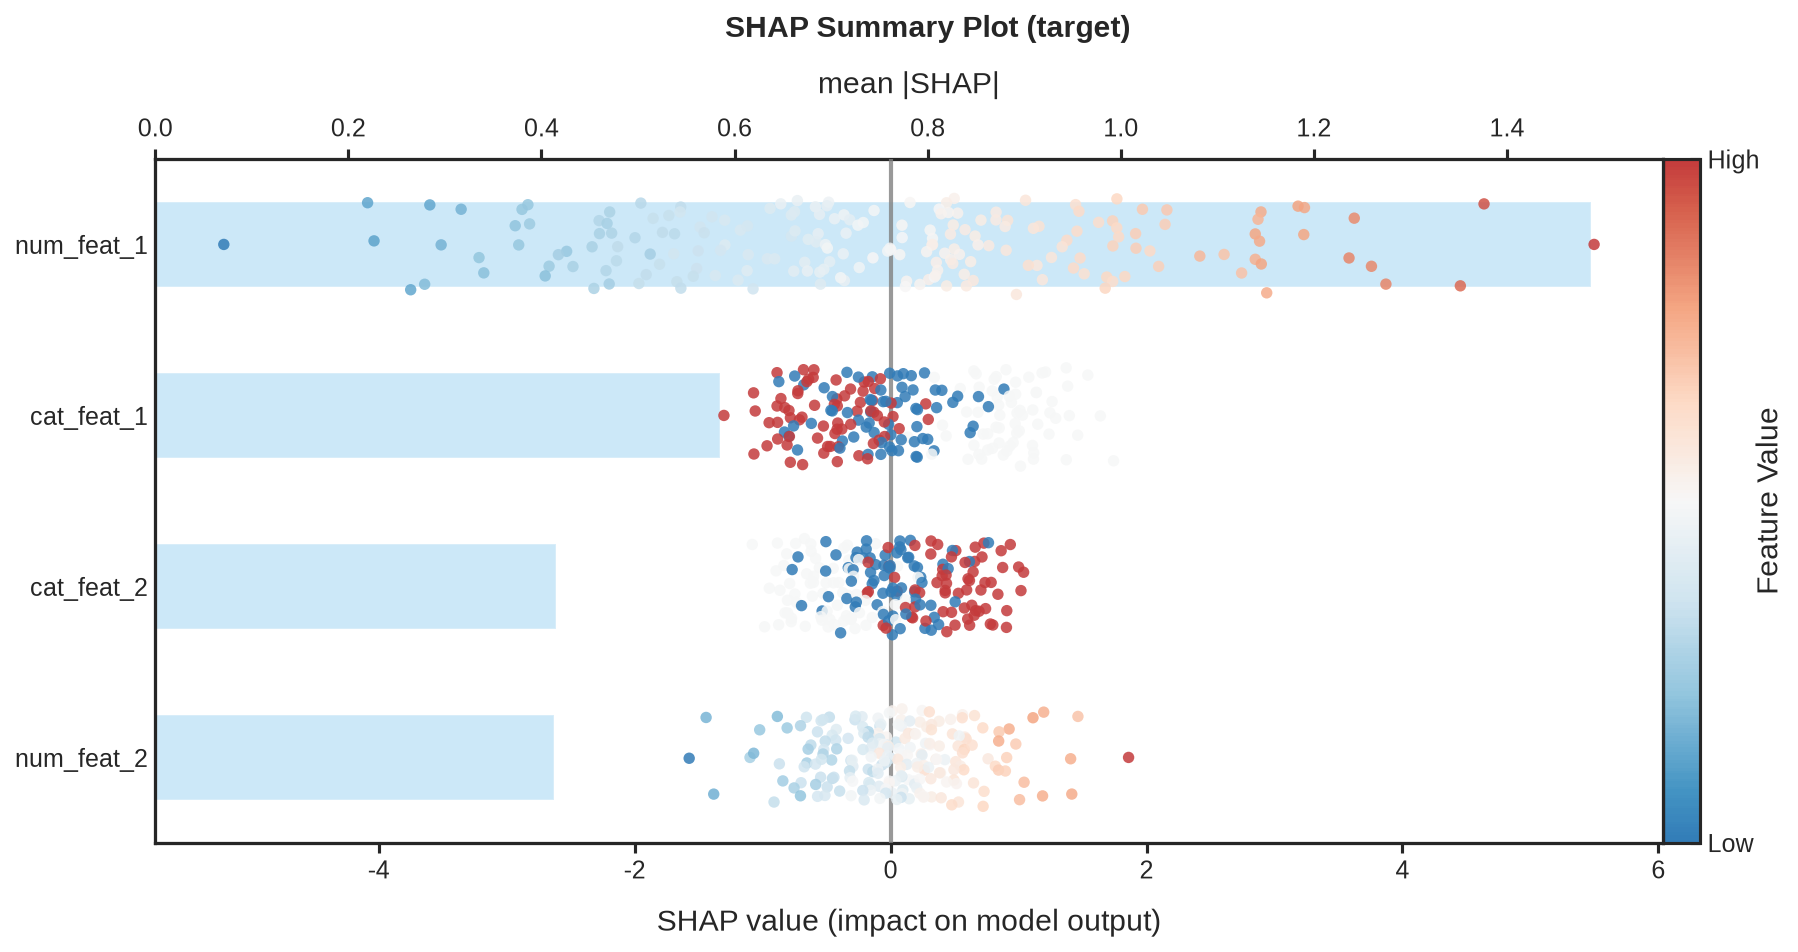

In [44]:
import shap
from lib.compute.plots.model_interpretability.shap.dependence import shap_dependence
from lib.compute.plots.model_interpretability.shap.summary import shap_summary

np.random.seed(42)

n_samples = 200

# 构造混合数据：2 数值列 + 2 分类列 (object dtype, 模拟 XGBoost enable_categorical 场景)
feat_names = ["num_feat_1", "num_feat_2", "cat_feat_1", "cat_feat_2"]
data = np.empty((n_samples, 4), dtype=object)
data[:, 0] = np.random.normal(0, 1, n_samples)
data[:, 1] = np.random.normal(0, 1, n_samples)
data[:, 2] = np.random.choice(["A", "B", "C"], n_samples)
data[:, 3] = np.random.choice(["low", "mid", "high"], n_samples)

rng = np.random.default_rng(42)
shap_vals = np.zeros((n_samples, 4))
shap_vals[:, 0] = data[:, 0].astype(float) * 2.0 + rng.normal(0, 0.2, n_samples)
shap_vals[:, 1] = data[:, 1].astype(float) * 0.5 + rng.normal(0, 0.2, n_samples)
# cat_feat_1: A>0, B<0, C≈0 的组间差异
cat_map = {"A": 1.0, "B": -0.5, "C": 0.0}
shap_vals[:, 2] = np.array([cat_map.get(v, 0) for v in data[:, 2]]) + rng.normal(0, 0.3, n_samples)
# cat_feat_2: 交互效应（低值正贡献、高值负贡献，中值近零）
cat_map2 = {"low": 0.5, "mid": 0.0, "high": -0.5}
shap_vals[:, 3] = np.array([cat_map2.get(v, 0) for v in data[:, 3]]) + rng.normal(0, 0.3, n_samples)
# cat_feat_1 和 cat_feat_2 的 SHAP 值有相关性 → 交互伙伴探测能识别
shap_vals[:, 2] += shap_vals[:, 3] * 0.3

base_values = np.zeros(n_samples)
explanation = shap.Explanation(
    values=shap_vals,
    base_values=base_values,
    data=data,
    feature_names=feat_names,
)

# 按 compute_shap_explanation 新协议：df.attrs 附带 categorical_features
cat_df = pd.DataFrame()
cat_df.attrs["explanation"] = explanation
cat_df.attrs["y_name"] = "target"
cat_df.attrs["categorical_features"] = ["cat_feat_1", "cat_feat_2"]
cat_df.attrs["suffix"] = "_target"

# === 1. Dependence 图：分类列 x 轴 category 名，无 LOWESS 曲线 ===
print("=== shap_dependence (4 features, 2 categorical + 2 numeric) ===")
_, fig_dep = next(shap_dependence(iter([cat_df]), top_n=4, col_wrap=2, with_fit=True))
fig_dep.subplots_adjust(left=0, right=1)
display(fig_dep)

# === 2. Summary 图：分类列 factorize 后归一化着色 ===
print("=== shap_summary (4 features, 2 categorical + 2 numeric) ===")
_, fig_sum = next(shap_summary(iter([cat_df])))
fig_sum.subplots_adjust(left=0, right=1)
display(fig_sum)

# EDA

## EDA 数据集

构造含数值/分类/缺失列的共享数据集。

In [13]:
eda_df = pd.DataFrame({
    "age": np.random.normal(40, 12, 300),
    "income": np.random.lognormal(10, 0.6, 300),
    "score": np.random.normal(70, 15, 300),
    "hours": np.random.gamma(2, 10, 300),
    "experience": np.random.normal(10, 5, 300),
    "category": np.random.choice(["A", "B", "C", "D", "E"], 300),
    "rare_cat": np.random.choice(["X", "Y", "Z", np.nan], 300, p=[0.05, 0.85, 0.05, 0.05]),
    "target_price": np.random.normal(200, 50, 300),
})
eda_df["income"] = eda_df["age"] * 50 + np.random.normal(0, 200, 300)
eda_df.loc[eda_df.sample(frac=0.15).index, "income"] = np.nan
eda_df.loc[eda_df.sample(frac=0.08).index, "score"] = np.nan
eda_df.loc[eda_df.sample(frac=0.25).index, "hours"] = np.nan
eda_df["target_price"] = eda_df["income"].fillna(50) * 0.3 + eda_df["age"] * 10 + np.random.normal(0, 30, 300)
eda_df.head()

,age,income,score,hours,experience,category,rare_cat,target_price
0,55.965263,2750.541784,77.155056,6.309433,10.391743,A,Y,1401.615617
1,63.991806,NaN,35.846310,16.742334,7.225641,A,Y,594.347488
2,48.617183,NaN,73.712467,9.361199,5.787998,D,Y,490.085900
3,58.811133,NaN,103.756822,NaN,12.052379,E,Y,601.863077
4,25.866574,NaN,89.879036,NaN,12.750475,C,Y,268.903483


## 相关性热力图 (correlation_heatmap)

模拟特征矩阵计算 Spearman 相关 + p 值显著性标注。

Matrix shape: (6, 6)


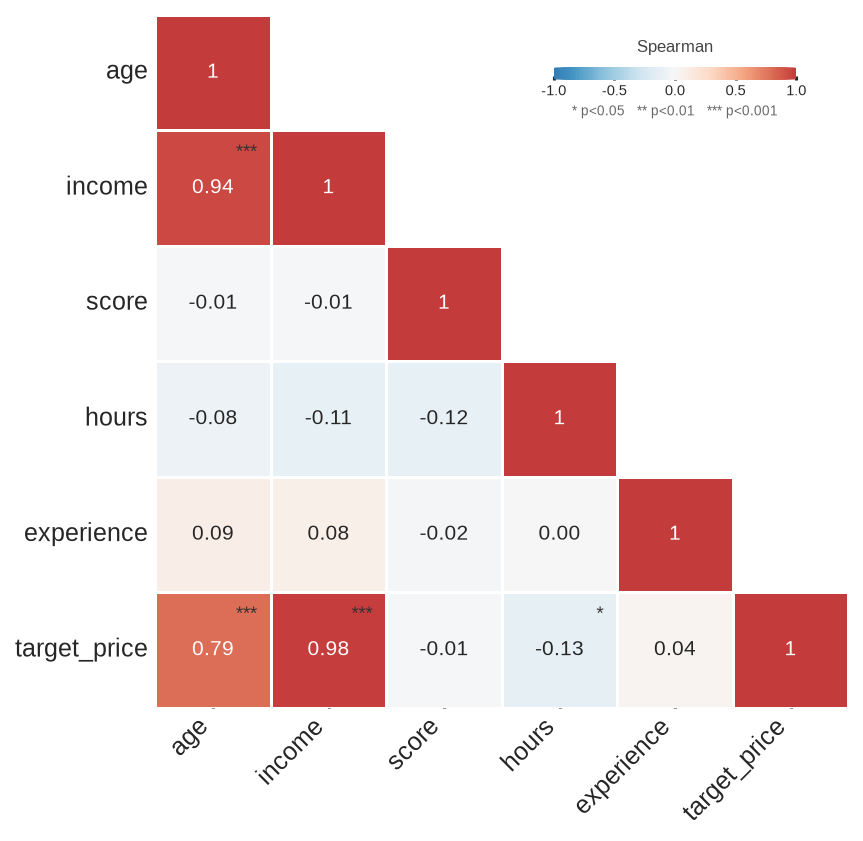

In [14]:
from lib.compute.plots.data_analysis.correlation_heatmap import correlation_heatmap

out_data, fig = correlation_heatmap(eda_df, targets=["target_price", "target_rating"], method="spearman")
corr_df, pval_df = out_data
print(f"Matrix shape: {corr_df.shape}")
display(fig)

## 多数值特征箱线图

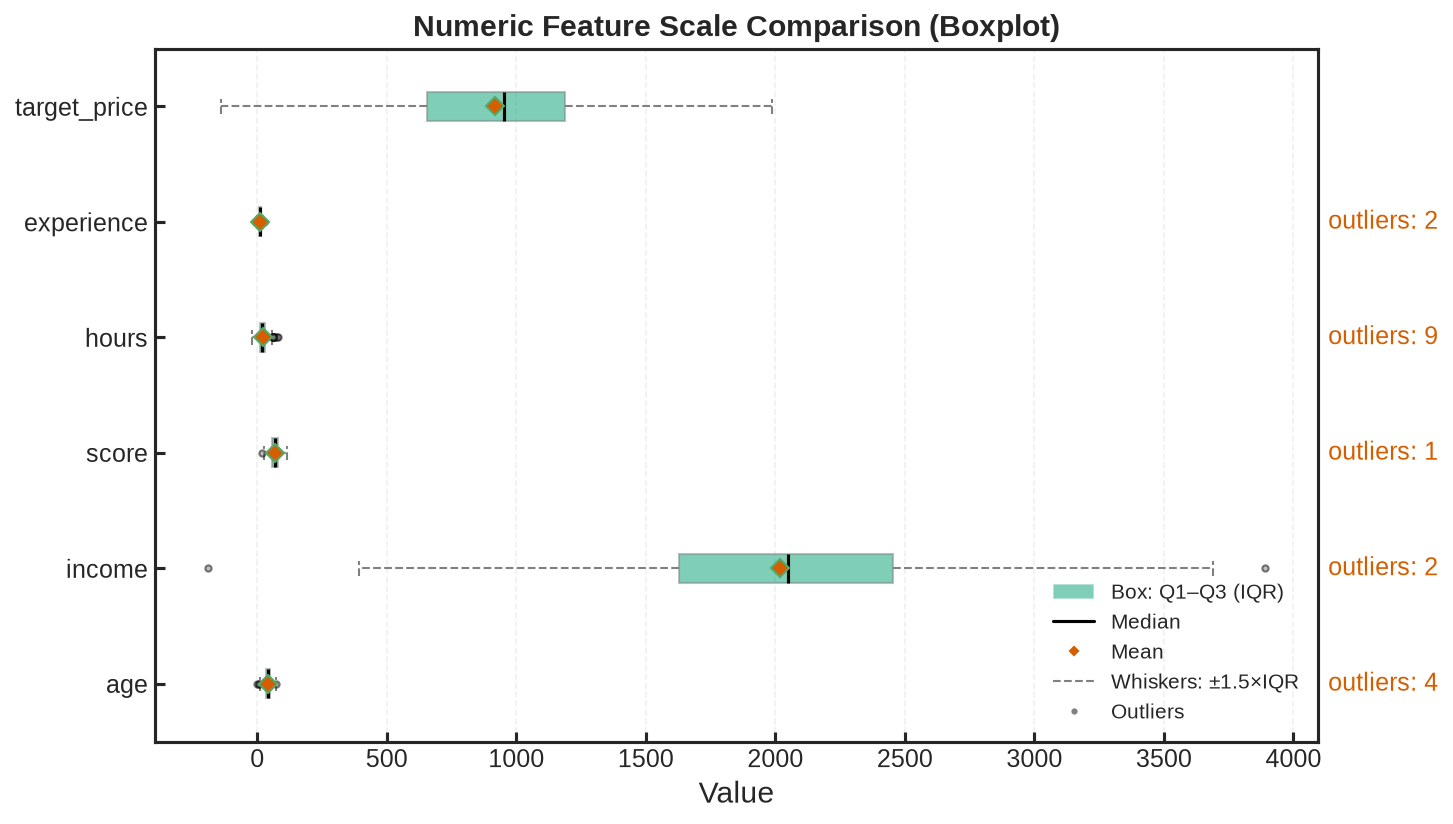

In [15]:
from lib.compute.plots.data_analysis.numeric_scale_box import numeric_scale_box

box_df, fig = numeric_scale_box(eda_df)
display(fig)

## 数值特征分布直方图

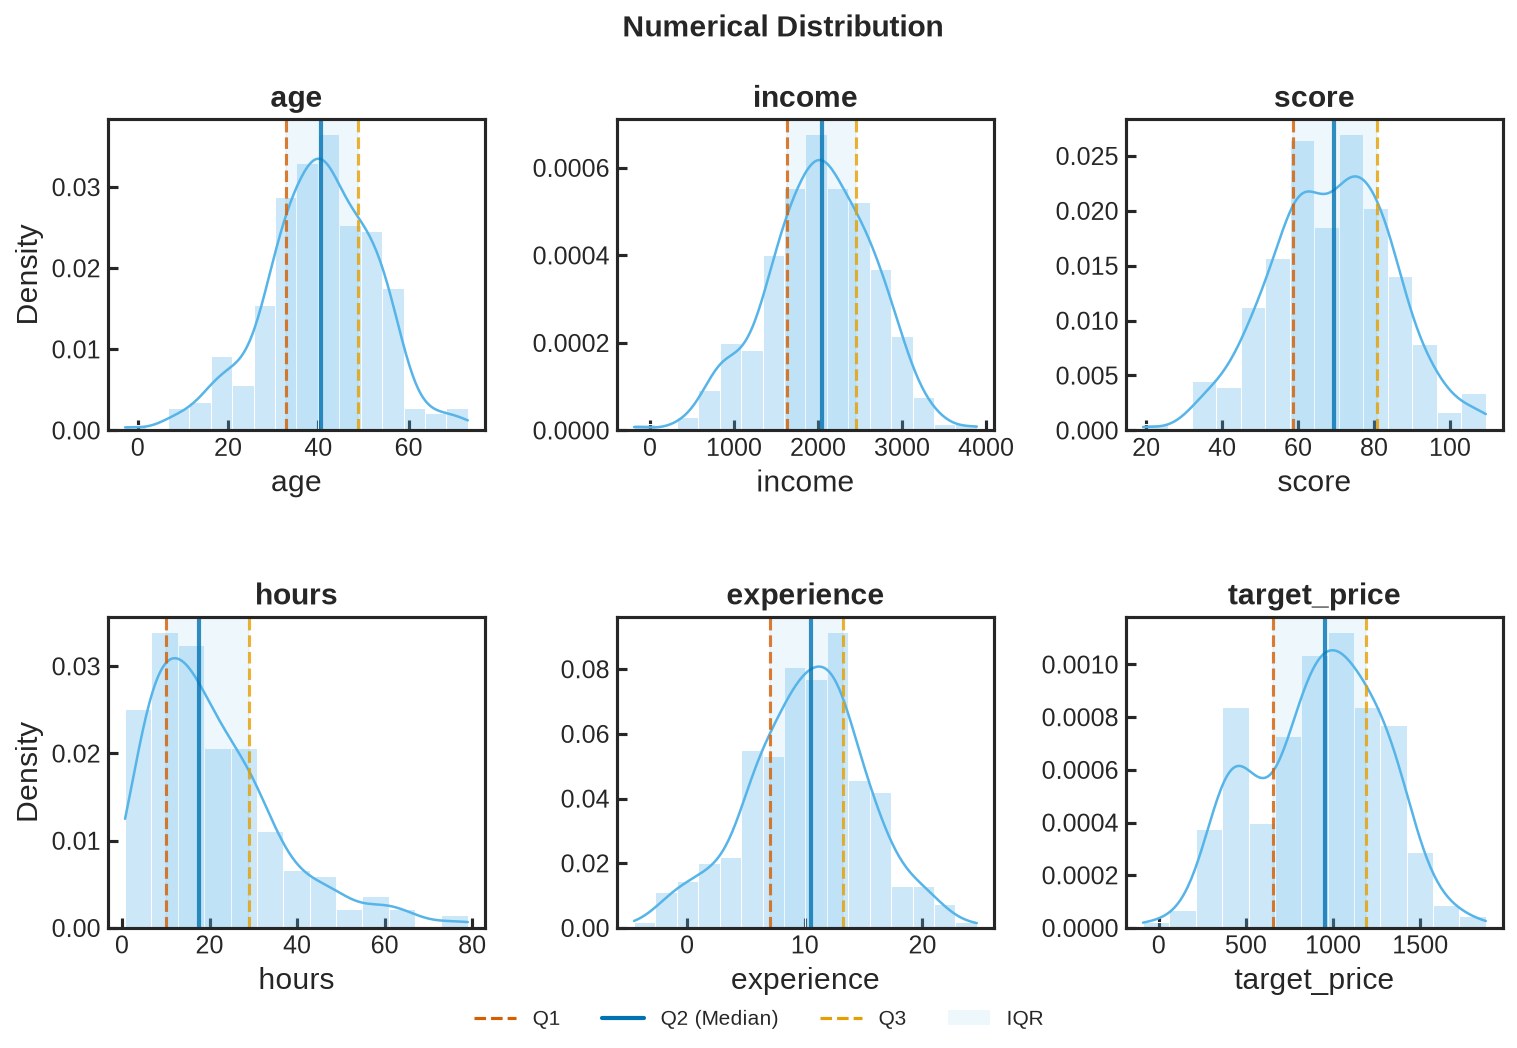

In [16]:
from lib.compute.plots.data_analysis.numeric_quality_kde_hist import numeric_quality_kde_hist


_, fig = numeric_quality_kde_hist(eda_df)
display(fig)

## 自变量-因变量趋势散点图 (target_trend_by_numeric)

行带布局：先遍历 targets、带内 top-k 相关特征按 col_wrap 折行（列数 = min(特征数, col_wrap)）+ LOWESS 趋势线；每 target 仅 1 个特征时多 target 连续排布共享行，全部 target 拼单张 figure。

测试场景：
1. 多目标-多特征：双行带，各 target 的 top_k 特征集独立选取
2. 单目标-多特征：top_k 按 |r| 自动选特征
3. 多目标-单特征：显式 numerical_cols，全单特征 → 多 target 连续排布共享行
4. 单目标-单特征：最小形态


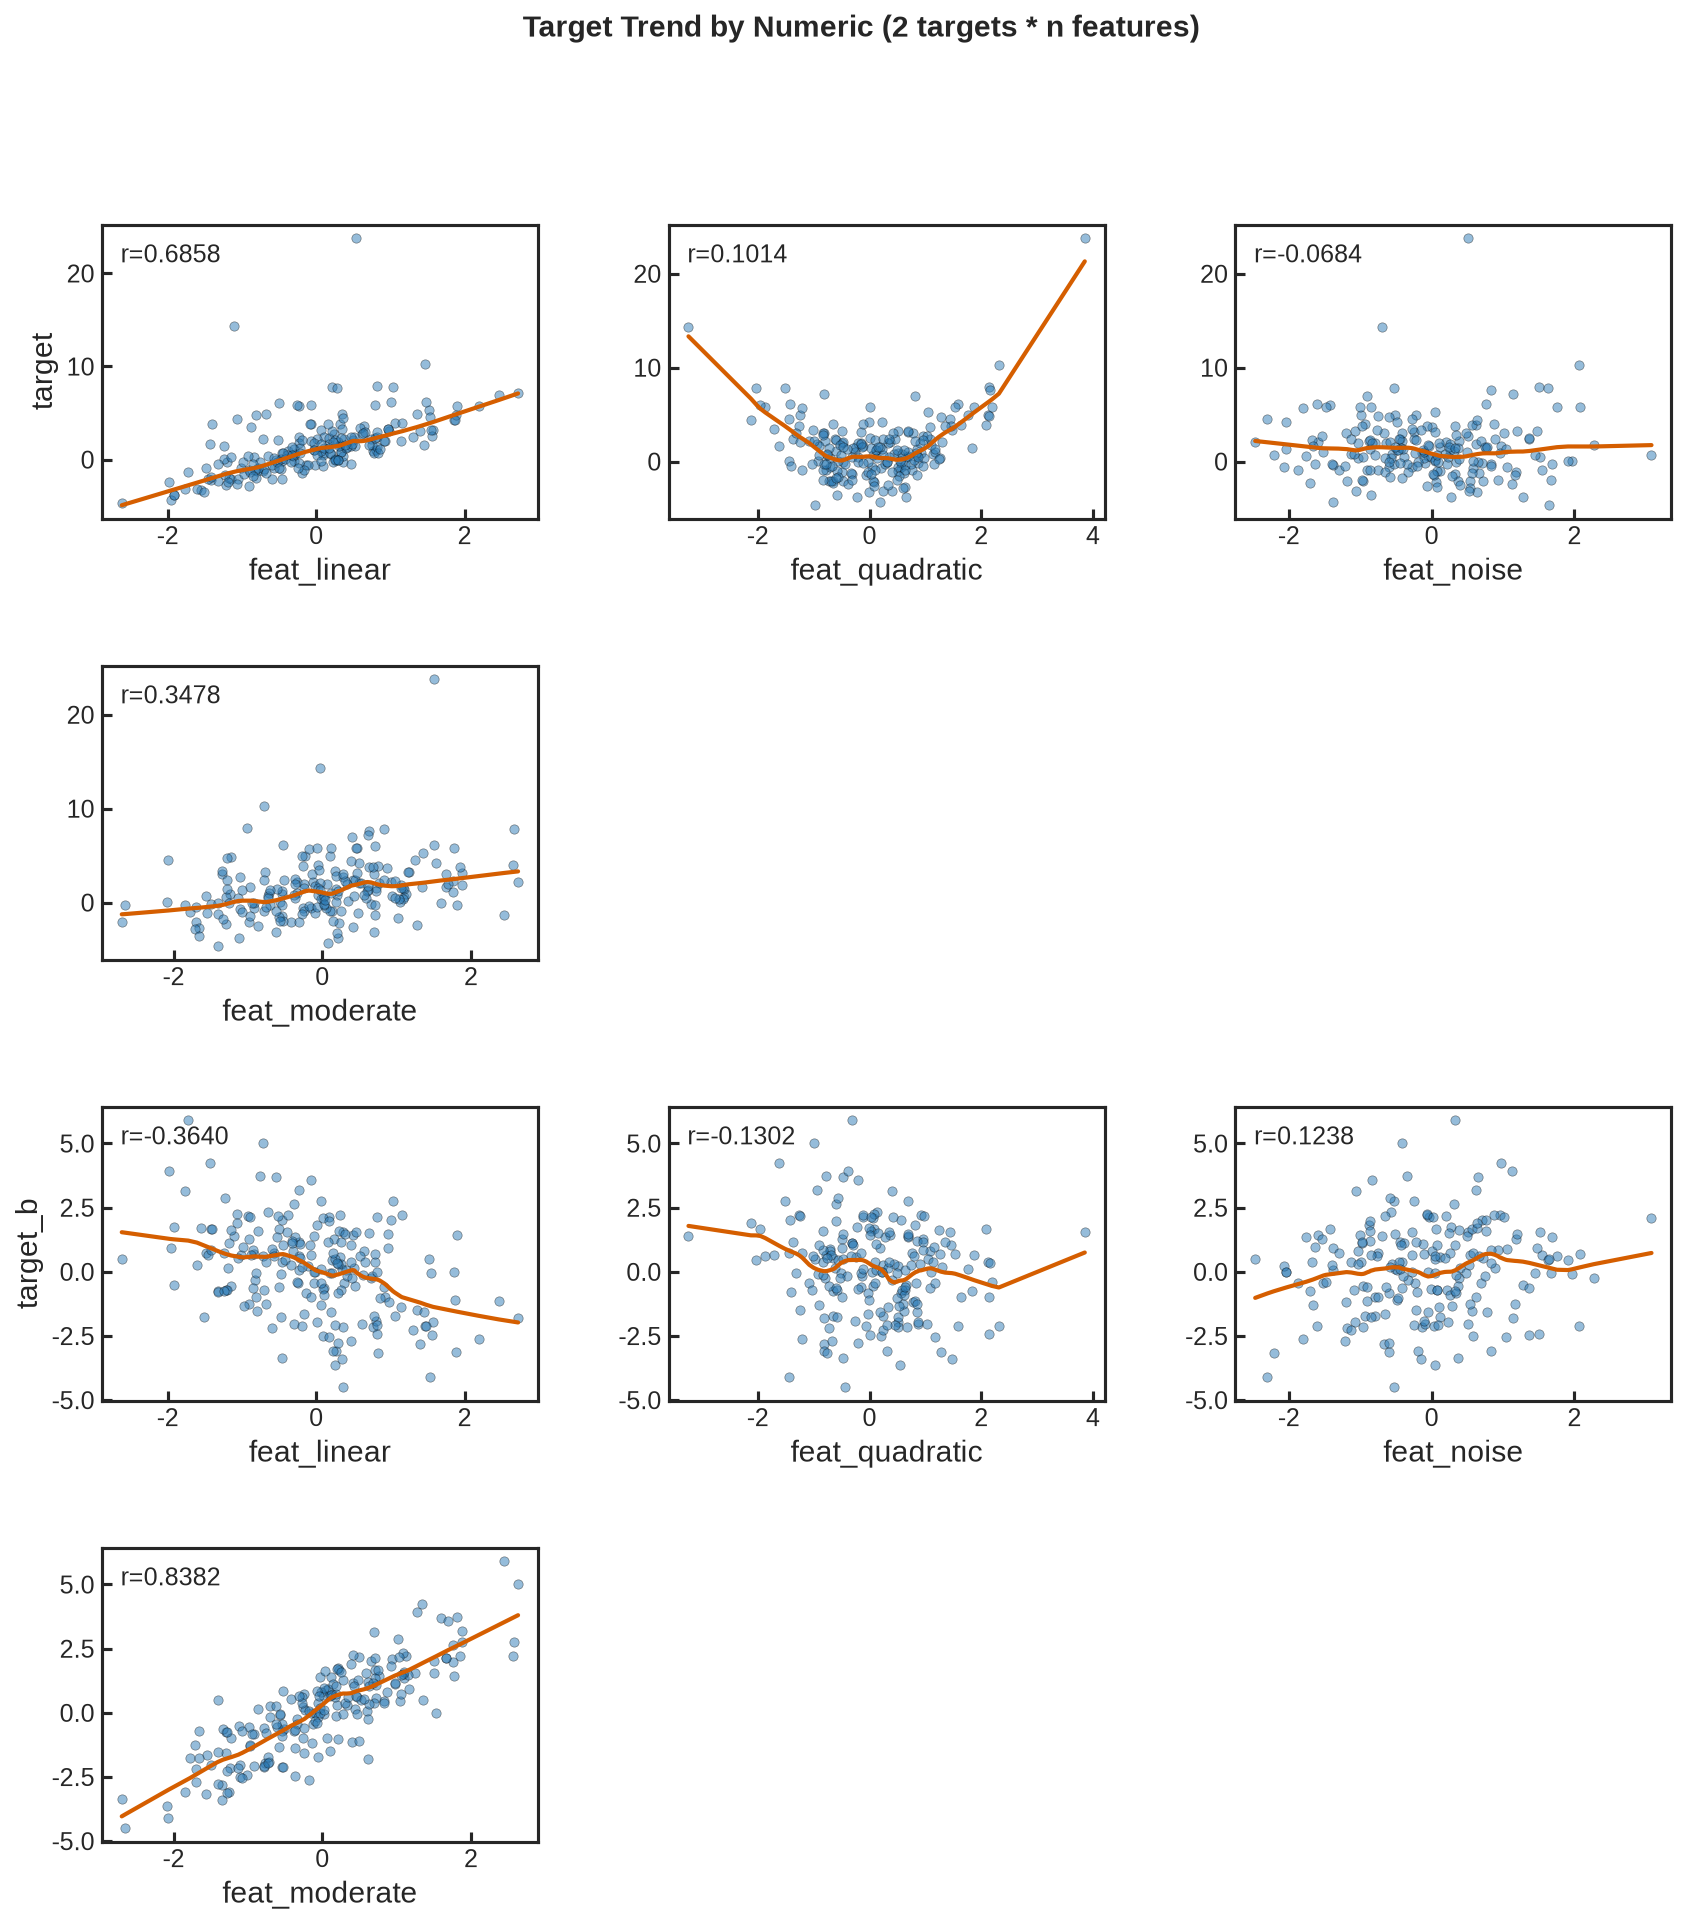

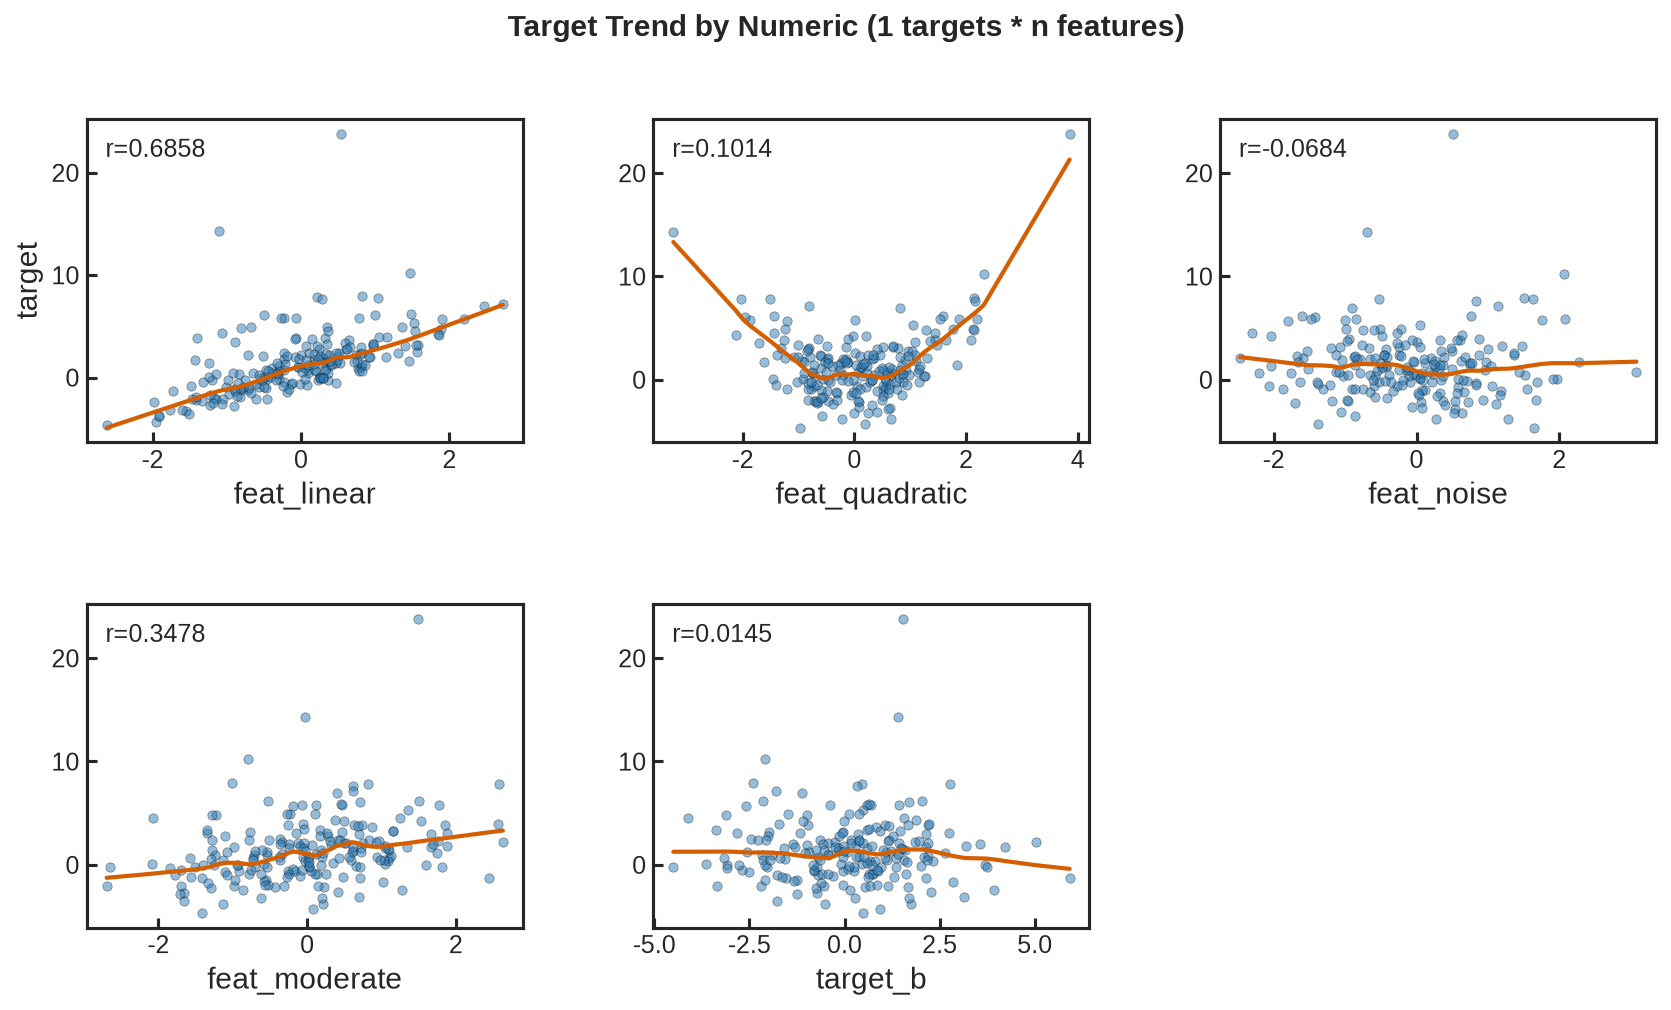

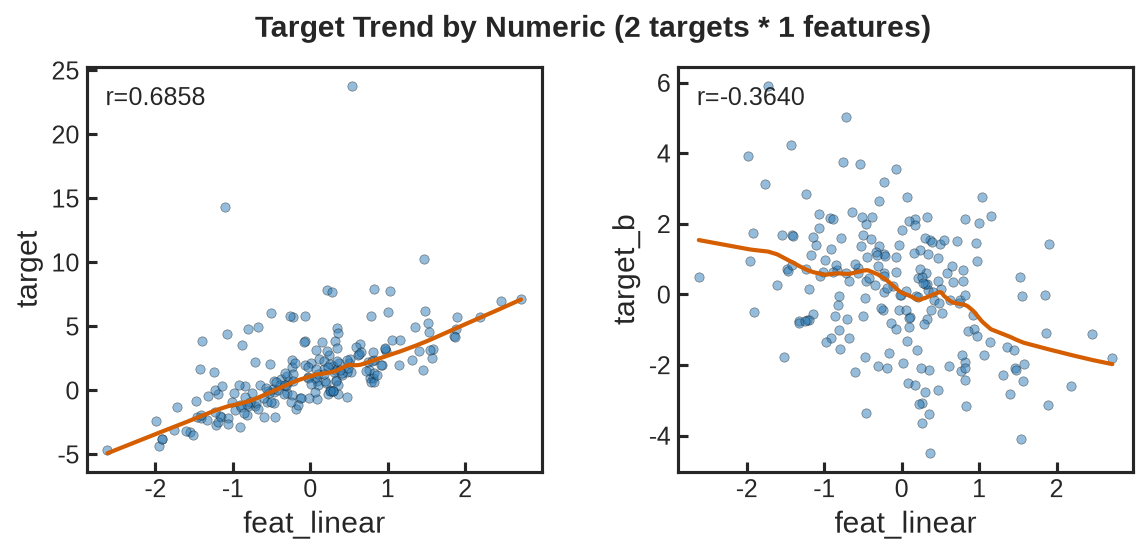

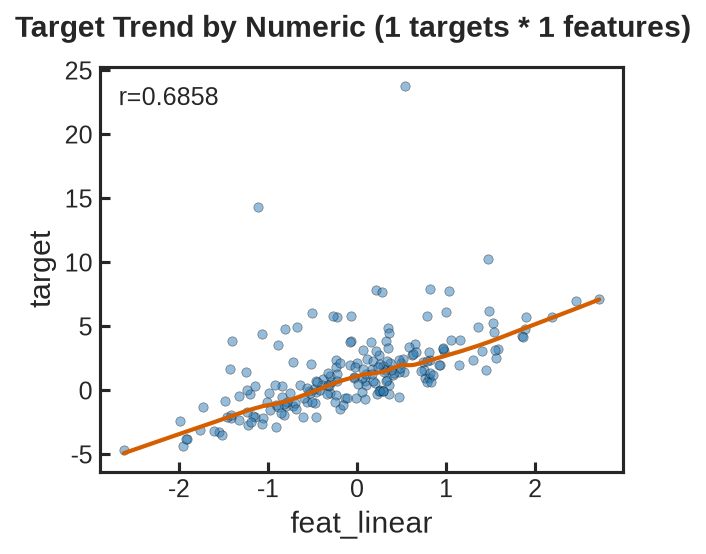

In [17]:
from lib.compute.plots.data_analysis.target_trend_by_numeric import target_trend_by_numeric

np.random.seed(42)

n = 200
df = pd.DataFrame(
    {
        "feat_linear": np.random.normal(0, 1, n),
        "feat_quadratic": np.random.normal(0, 1, n),
        "feat_noise": np.random.normal(0, 1, n),
        "feat_moderate": np.random.normal(0, 1, n),
    }
)
df["target"] = df["feat_linear"] * 2.0 + df["feat_quadratic"] ** 2 * 1.5 + df["feat_moderate"] * 0.6 + np.random.normal(0, 0.5, n)
df["target_b"] = df["feat_moderate"] * 1.5 - df["feat_linear"] * 0.8 + np.random.normal(0, 0.5, n)

# 场景 1：多目标-多特征 —— 2 targets 各自 top_k 特征（特征集可不同），每 target 一段行带
dfs, fig = target_trend_by_numeric(df, targets=["target", "target_b"], lowess_frac=0.3, title="Target Trend by Numeric (2 targets * n features)")
display(fig)

# 场景 2：单目标-多特征 —— top_k 按 |r| 自动选取
dfs, fig2 = target_trend_by_numeric(df, targets="target", col_wrap=3, lowess_frac=0.3, title="Target Trend by Numeric (1 targets * n features)")
display(fig2)

# 场景 3：多目标-单特征 —— 显式 numerical_cols，两段行带各 1 格
dfs, fig3 = target_trend_by_numeric(df, targets=["target", "target_b"], numerical_cols="feat_linear", lowess_frac=0.3, title="Target Trend by Numeric (2 targets * 1 features)")
display(fig3)

# 场景 4：单目标-单特征 —— 最小形态
dfs, fig4 = target_trend_by_numeric(df, targets="target", numerical_cols="feat_linear", lowess_frac=0.3, title="Target Trend by Numeric (1 targets * 1 features)")
display(fig4)


## 目标组间效应图 (target_effect_by_category)

行带布局：先遍历数值 targets、带内 categorical_cols 按 col_wrap 折行（列数 = min(分类列数, col_wrap)），仅 1 个分类列时多 target 连续排布共享行；纯 KDE 多组叠加，targets 经 dtypes="number" 校验，分类目标报错（改用 target_association_by_category）。

组间效应信号：均值位移 / 方差差异 / 形态差异（类内双峰）/ 异常值集中某类 / 全重叠（采样维度读法=平衡）。

测试场景：
1. 多目标-多特征：5 个数值 target × 2 分类列，行带垂直堆叠拼单张 figure
2. 单目标-多特征：单行带内按 col_wrap 折行
3. 多目标-单特征：全单特征 → 多 target 连续排布共享行
4. 单目标-单特征：最小形态


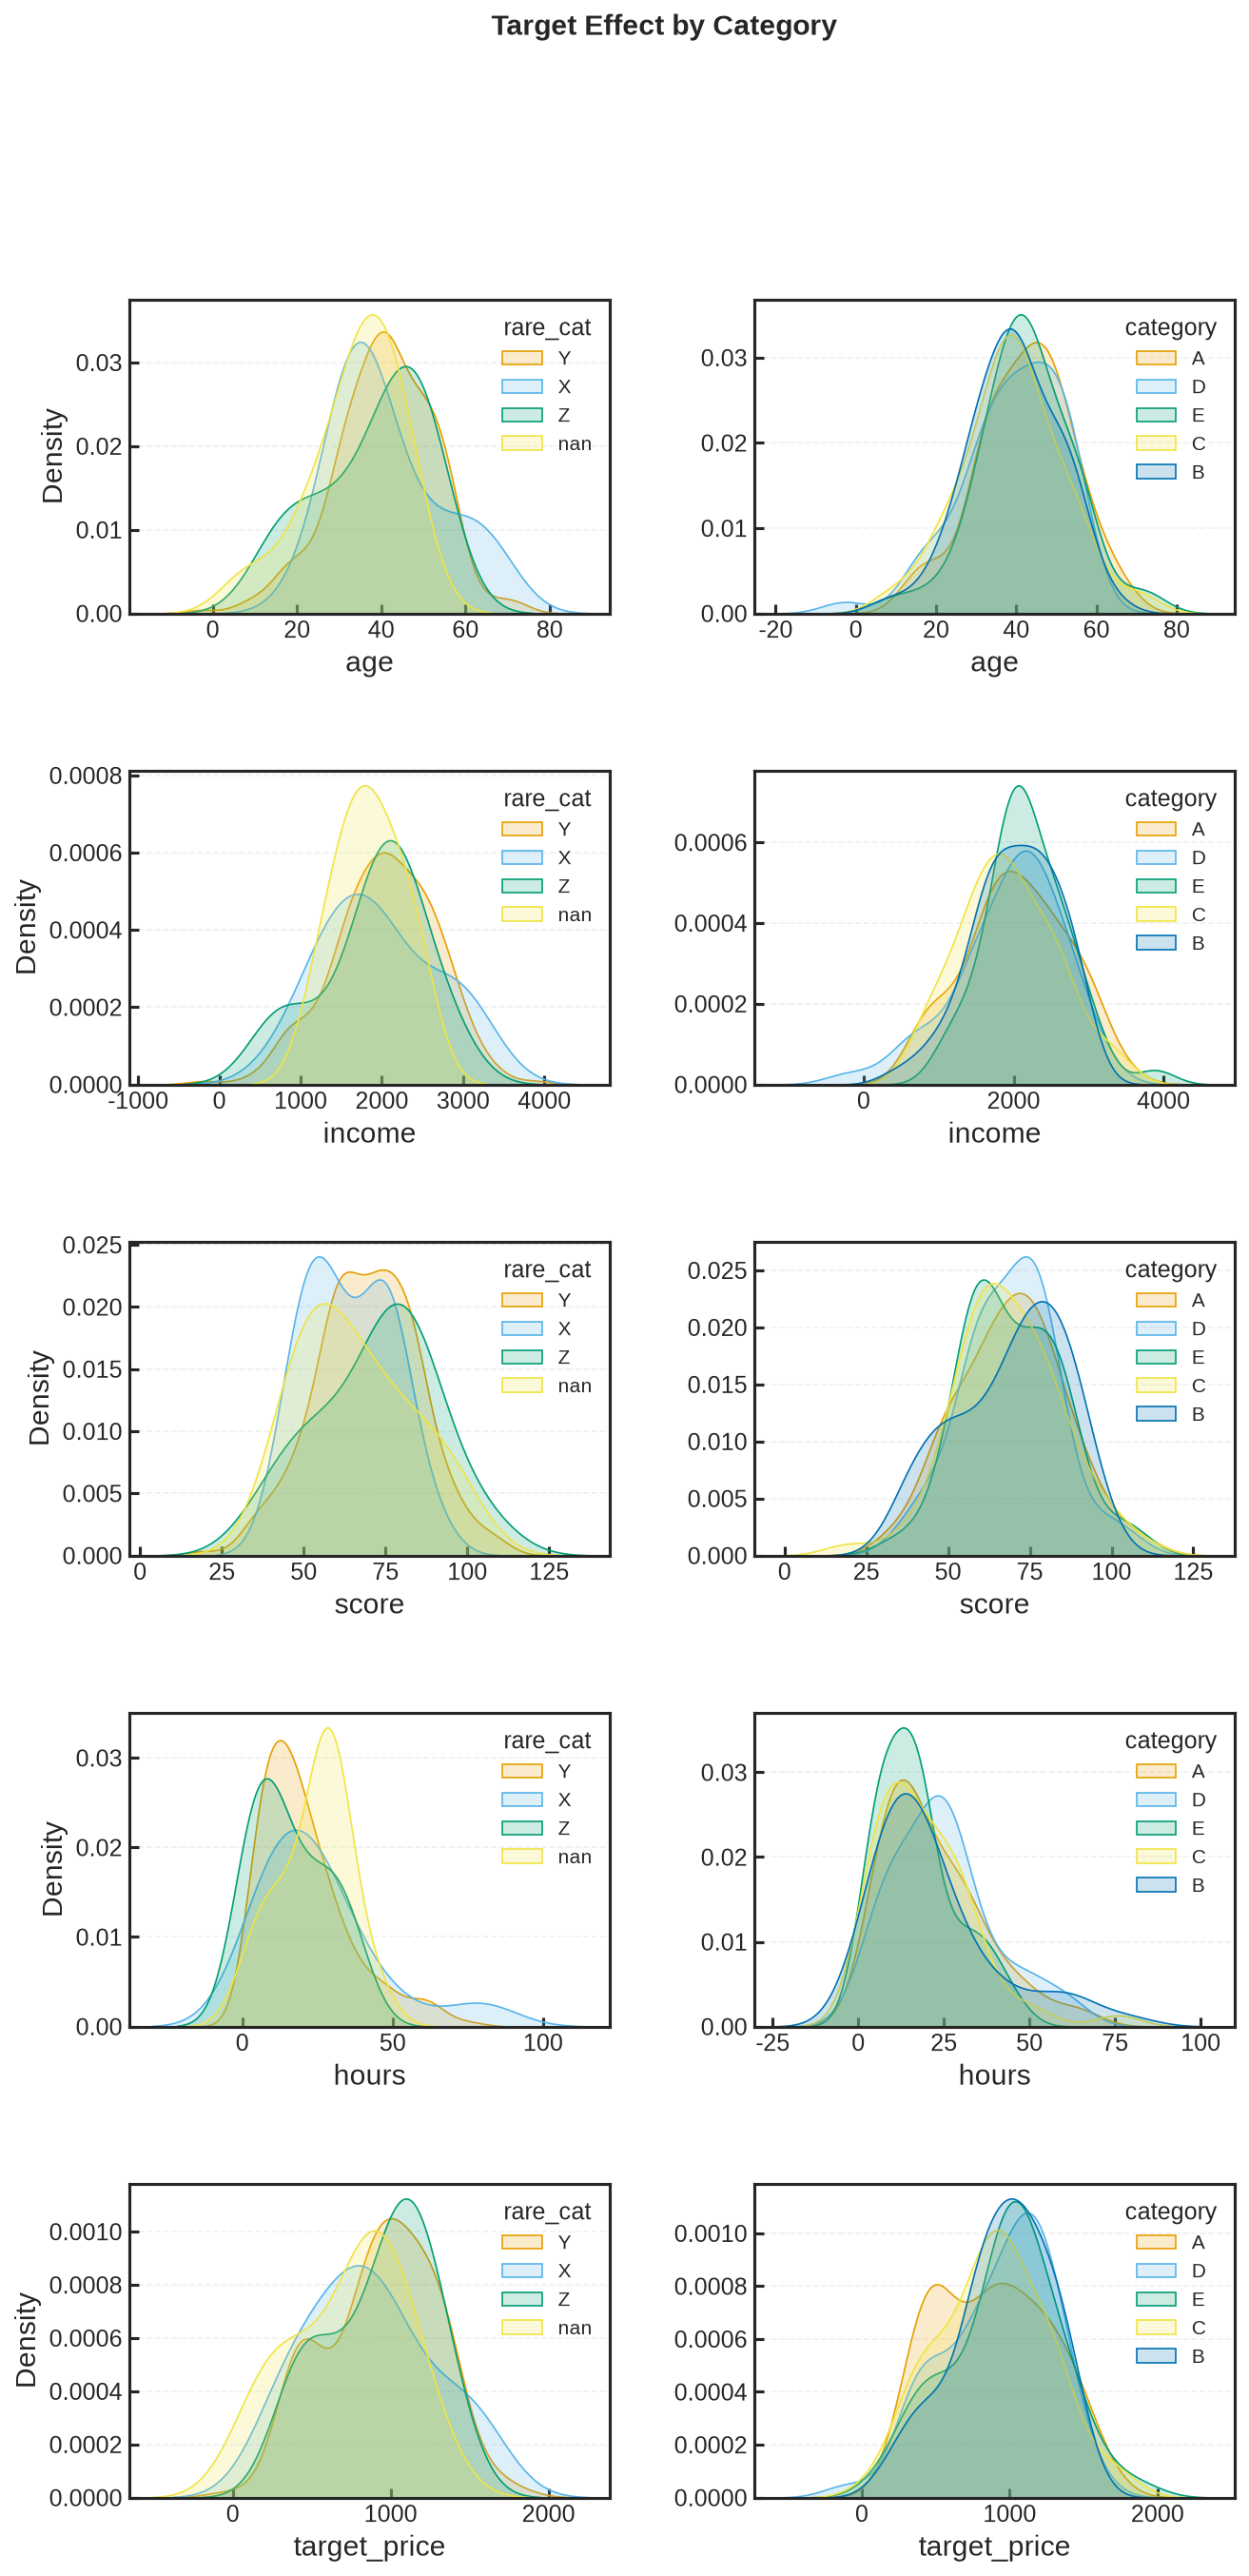

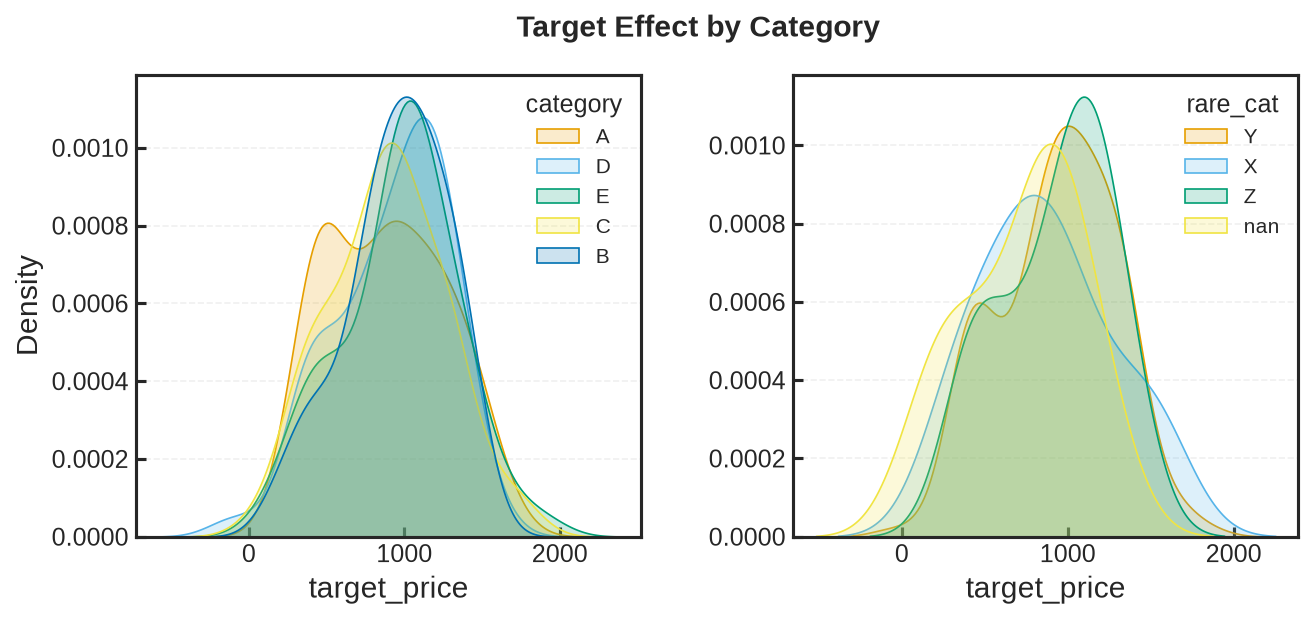

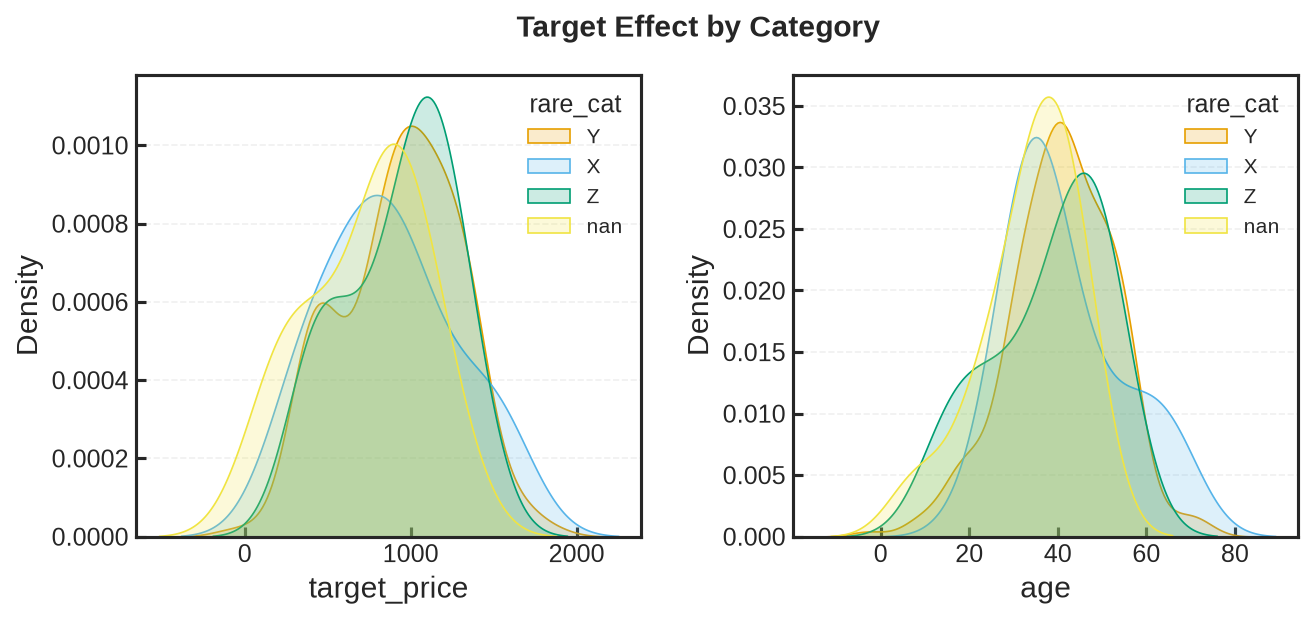

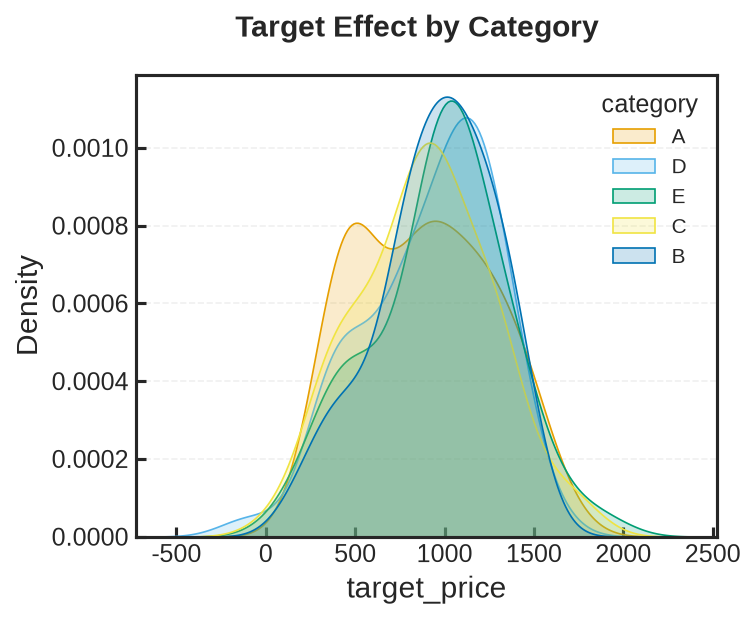

In [18]:
from lib.compute.plots.data_analysis.target_effect_by_category import target_effect_by_category

# 场景 1：多目标-多特征 —— 5 个数值 target × 2 分类列，每 target 一段行带
_, fig = target_effect_by_category(
    eda_df,
    targets=["age", "income", "score", "hours", "target_price"],
    categorical_cols=["rare_cat", "category"],
)
display(fig)

# 场景 2：单目标-多特征 —— 单行带内按 col_wrap 折行
_, fig2 = target_effect_by_category(eda_df, targets=["target_price"], categorical_cols=["category", "rare_cat"])
display(fig2)

# 场景 3：多目标-单特征 —— 全单特征，连续排布共享行
_, fig3 = target_effect_by_category(eda_df, targets=["target_price", "age"], categorical_cols=["rare_cat"])
display(fig3)

# 场景 4：单目标-单特征 —— 最小形态
_, fig4 = target_effect_by_category(eda_df, targets=["target_price"], categorical_cols="category")
display(fig4)


## 目标类别分离度图 (target_separation_by_numeric)

补齐"数值特征 × 分类目标"象限：每格对一个数值特征按目标类别做 KDE 叠加，类别分离明显 = 特征有判别力。阅读预期与 balance 相反（balance 期望重叠=平衡，本图期望分离=特征有效）。

测试场景：
1. 多目标-多特征：双行带，各带内特征按 col_wrap 折行
2. 单目标-多特征：feat_strong 应明显分离 / feat_noise 应重叠（对照）
3. 多目标-单特征：全单特征 → 多 target 连续排布共享行
4. 单目标-单特征：最小形态


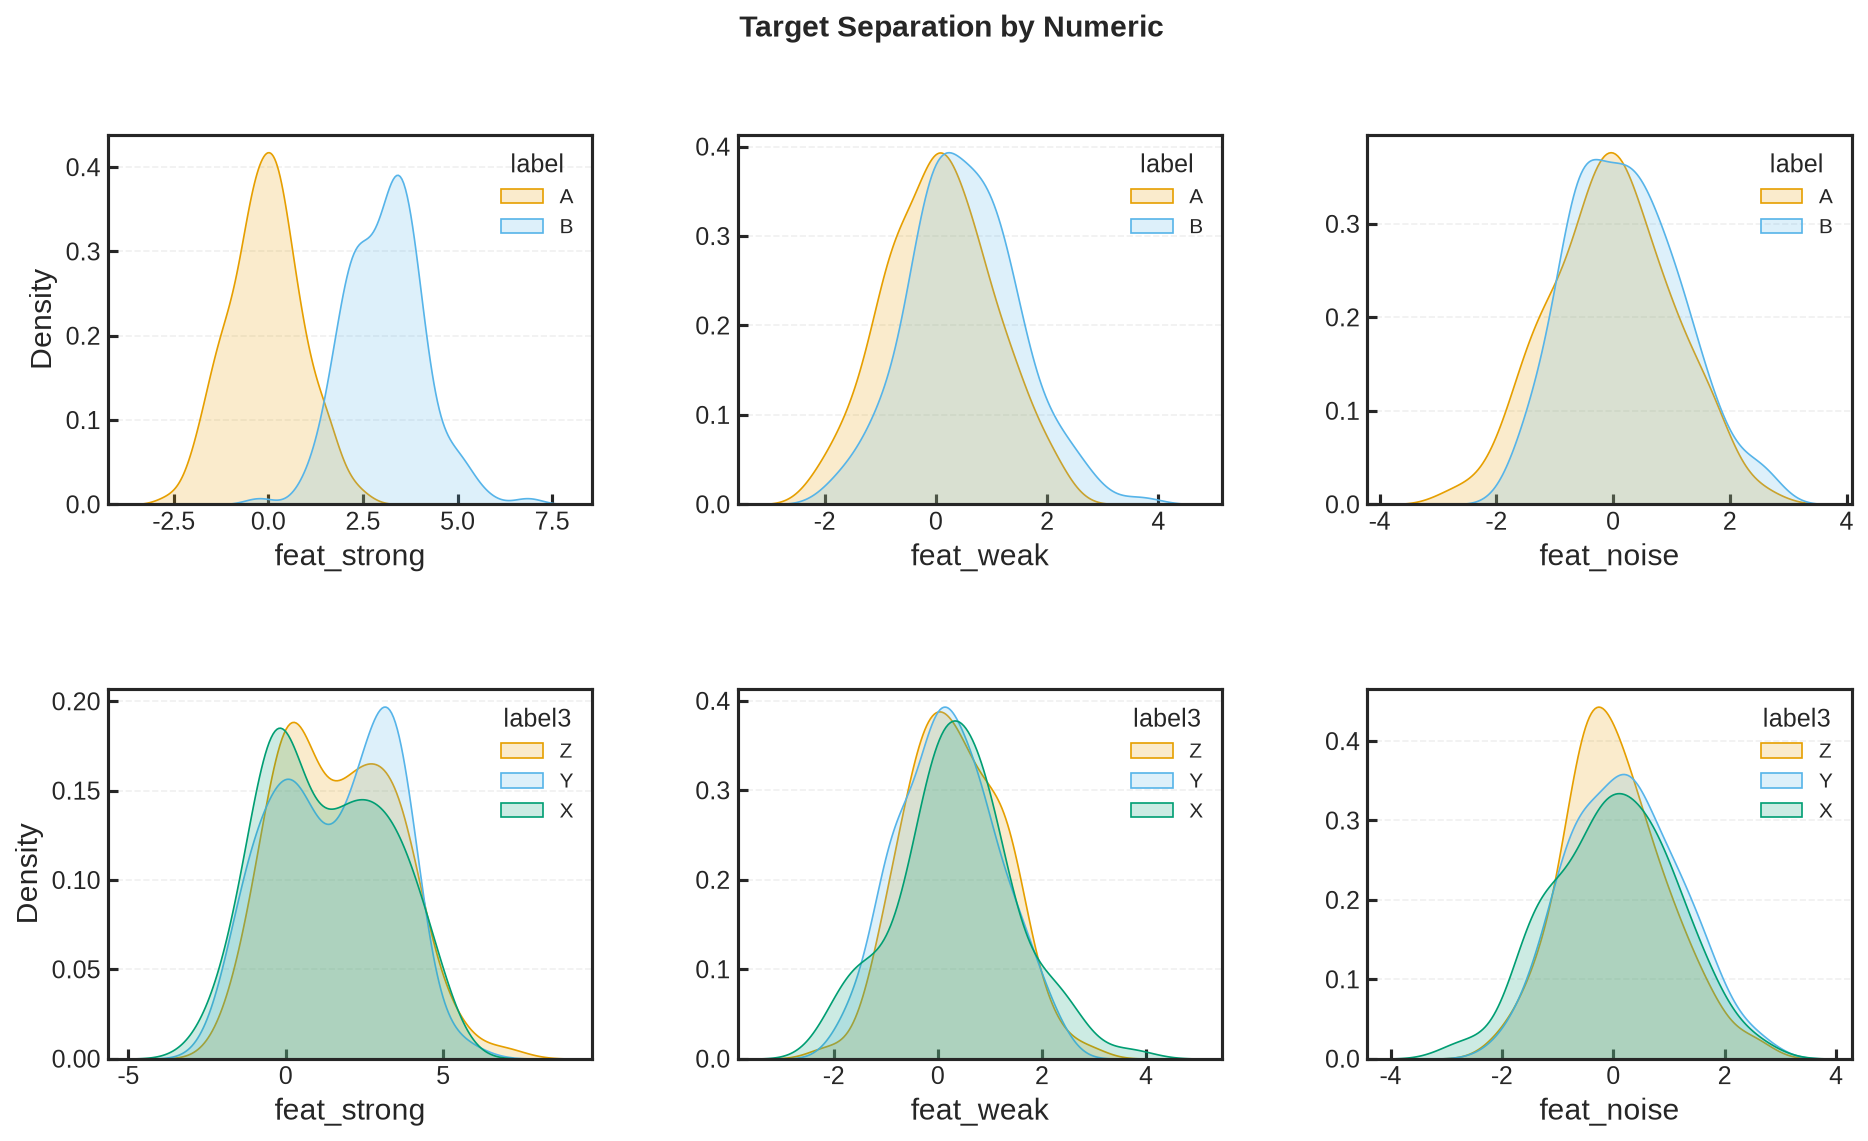

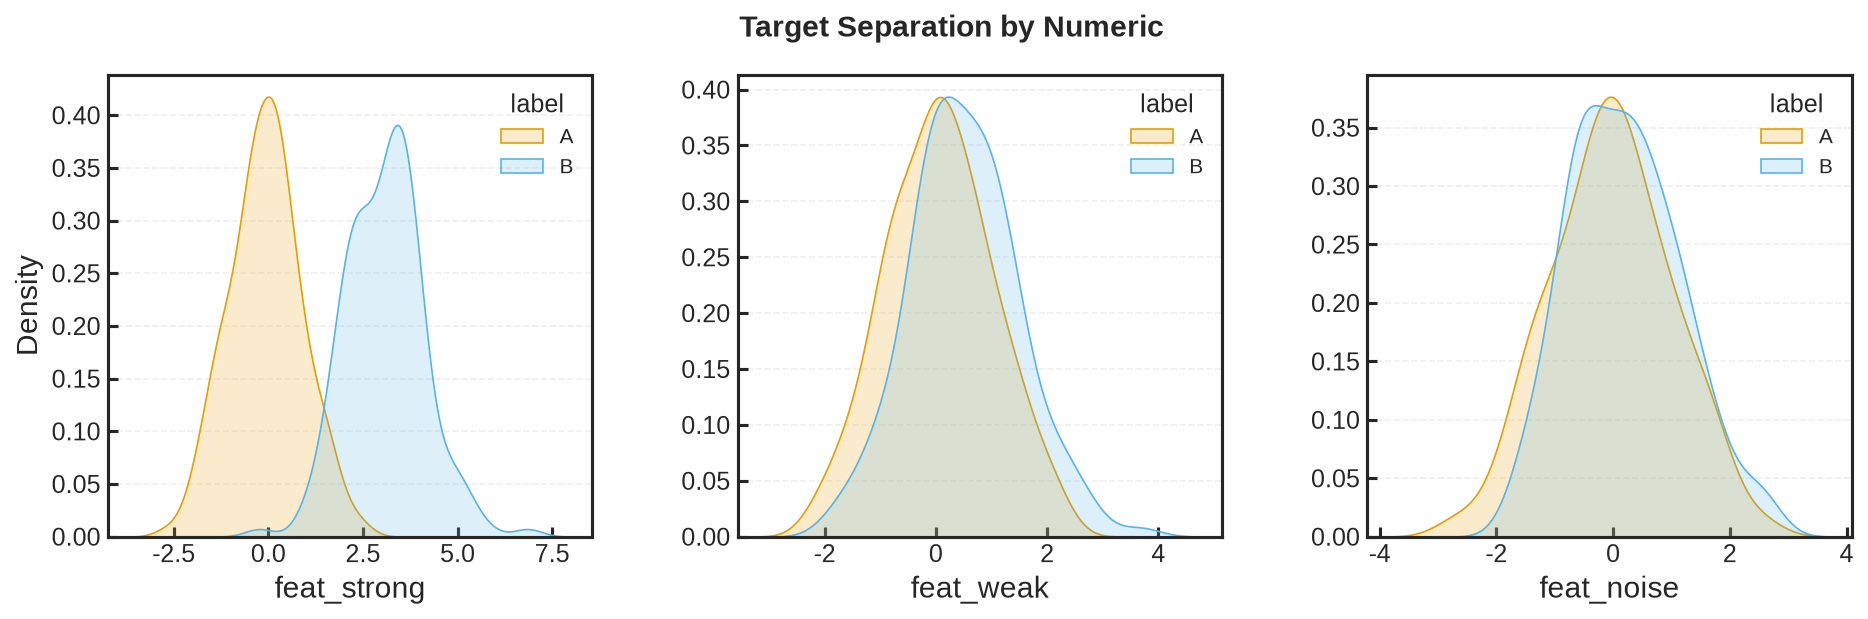

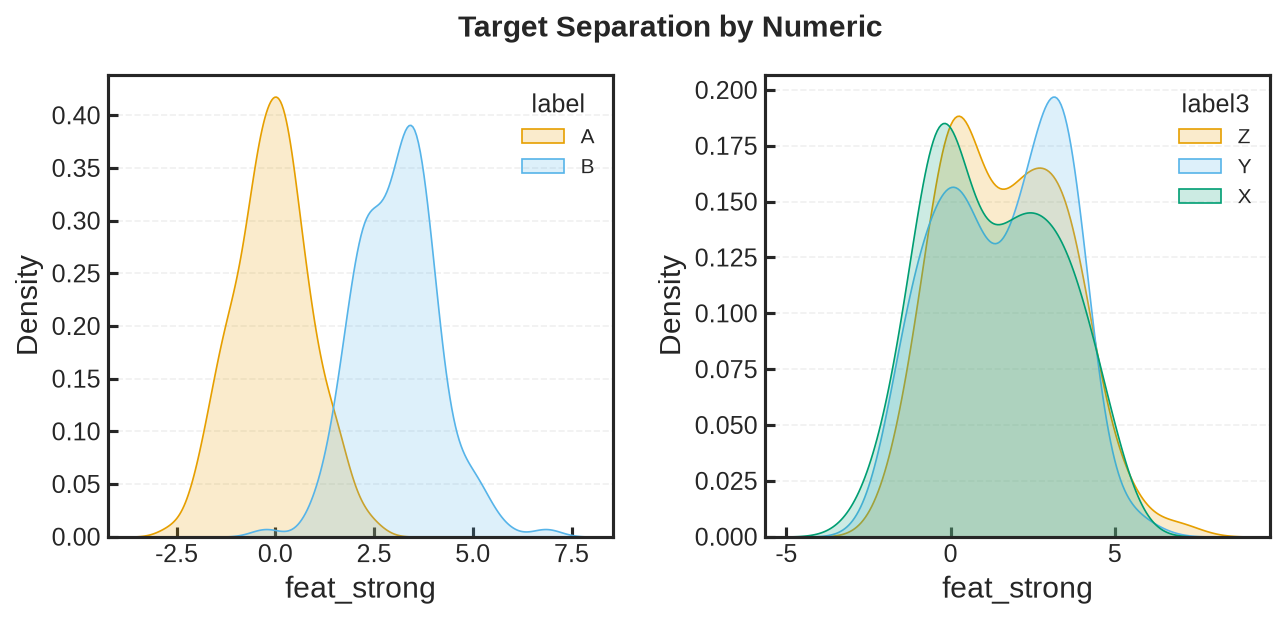

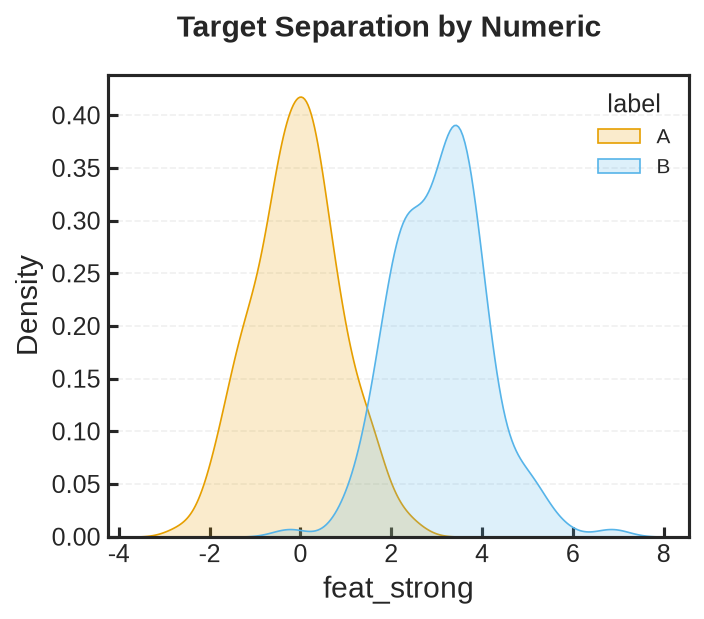

In [19]:
from lib.compute.plots.data_analysis.target_separation_by_numeric import target_separation_by_numeric

np.random.seed(42)
n = 300
half = n // 2
clf_df = pd.DataFrame({
    "feat_strong": np.r_[np.random.normal(0, 1, half), np.random.normal(3, 1, half)],
    "feat_weak": np.r_[np.random.normal(0, 1, half), np.random.normal(0.6, 1, half)],
    "feat_noise": np.random.normal(0, 1, n),
    "label": ["A"] * half + ["B"] * half,
})
clf_df["label3"] = np.random.choice(["X", "Y", "Z"], n)

# 场景 1：多目标-多特征 —— 双行带
_, fig = target_separation_by_numeric(clf_df, targets=["label", "label3"])
display(fig)

# 场景 2：单目标-多特征 —— feat_strong 分离 / feat_noise 重叠对照
_, fig2 = target_separation_by_numeric(clf_df, targets="label")
display(fig2)

# 场景 3：多目标-单特征 —— 连续排布共享行
_, fig3 = target_separation_by_numeric(clf_df, targets=["label", "label3"], numerical_cols="feat_strong")
display(fig3)

# 场景 4：单目标-单特征 —— 最小形态
_, fig4 = target_separation_by_numeric(clf_df, targets="label", numerical_cols="feat_strong")
display(fig4)


## 目标类别关联图 (target_association_by_category)

补全"分类特征 × 分类目标"象限：每格交叉表热力图（行=特征类别，列=target 类别，x 轴统一为 target），单元格标注频数。

类别关联信号：行模式差异（构成比随类别变化）/ 对角集中（嵌套混杂或泄漏）/ 空格（设计空洞）/ 各行等比一致（独立；采样维度读法=分层平衡）。注意原始计数受边际频数影响。


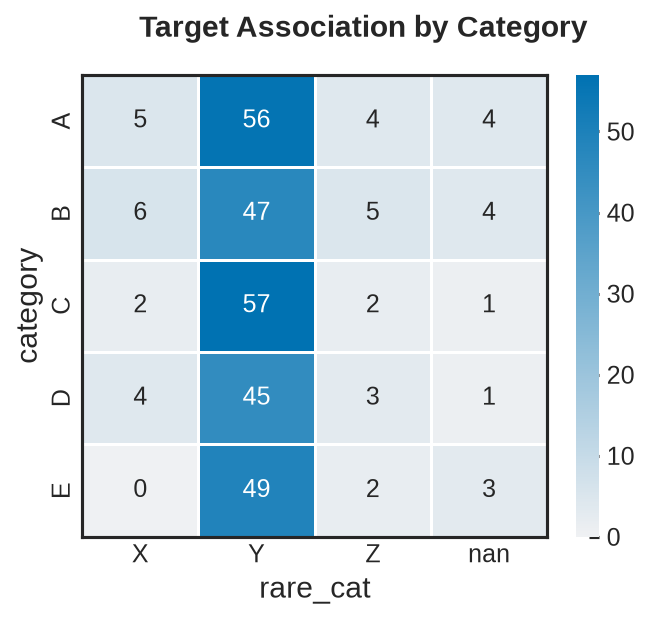

~/mflowy/lib/compute/plots/data_analysis/_grid.py:42: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(


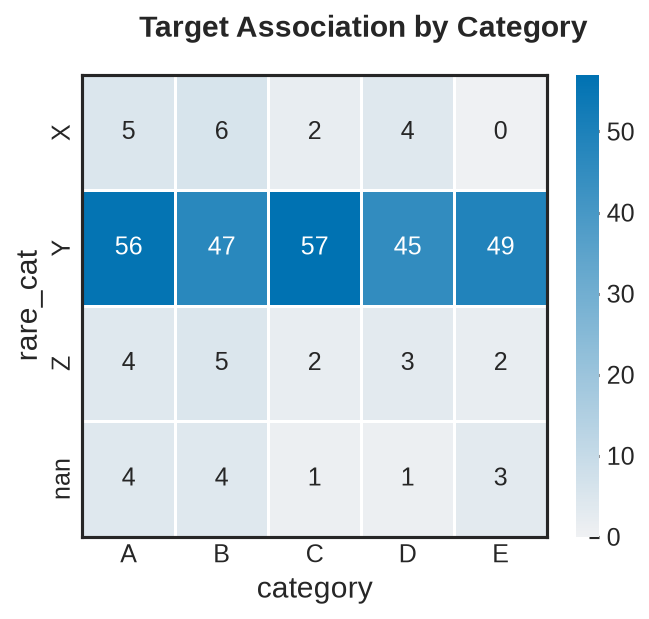

In [20]:
from lib.compute.plots.data_analysis.target_association_by_category import target_association_by_category

# rare_cat 作分类目标 × category 作分类特征
_, fig = target_association_by_category(eda_df, targets="rare_cat", categorical_cols="category")
display(fig)

# 角色对调（关联本身对称，方向只影响轴向）
_, fig2 = target_association_by_category(eda_df, targets="category", categorical_cols="rare_cat")
display(fig2)
